In [1]:
from itertools import product
import psutil
from functools import partial
import sys
# !{sys.executable} --version
# !{sys.executable} -m pip install shap --upgrade 
from qiskit_addon_sqd.counts import counts_to_arrays, bit_array_to_arrays
from tqdm.notebook import tqdm
import joblib
import time
from shutil import copy
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, r2_score
import os
import matplotlib.pyplot as plt
from glob import glob
import seaborn as sns 
from tqdm.notebook import tqdm
from matplotlib import font_manager
import scipy.stats as stats
from shutil import move
font_path = 'Futura Book.ttf'
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path, size='large')
plt.rcParams['font.family'] = prop.get_name()
plt.rcParams.update({'font.size': 12})




In [2]:
65370+9281

74651

In [3]:
# from qiskit_ibm_runtime import QiskitRuntimeService

# service = QiskitRuntimeService(
#     channel='ibm_quantum_platform',
#     instance='crn:v1:bluemix:public:quantum-computing:us-east:a/d2c50f33c43a44abb94280706332351d:21577587-df3e-4814-9e65-9c35f3e49ac9::'
# )

# GMJ plot ideas
- Deviation from standard LUCJ (CCSD t1/t2 amps)
- Deviation of all initializations from HCI? (Maybe useless for this case; see point 1)
- Something to highlight SQDs "robustness" regarding initialization
    - Deviation from standard LUCJ (CCSD t1/t2 amps) but use barplot and explicitly highlight the GDB cases larger than 20 orbitals (see Kevin Sung where they mention initializations beyond 30 orbitals)
    - Boxplot deviations where the y-axis is deviations, x-axis is the basis set and the hue is the injection type
- Number of correct Hamming strings (ON vectors) *before* SQD

In [4]:
UofT_palette = [ "#1E3765",
                 "#007FA3", 
                 "#6D247A", 
                 "#DC4633",
                 "#6FC7EA",
                 "#00A189",
                 "#AB1368",
                 "#0D534D",
                 "#F1C500",
                 "#8DBF2E"
               ]

palette = sns.color_palette(UofT_palette)

In [5]:
energyDF=pd.read_csv("../../../classical/energies.csv",index_col=0)
moldf = pd.read_csv('molecules.csv')
activespacedf = pd.read_csv("active_spaces.csv")

In [6]:



# To get counts for a particular pub result, use
#
# pub_result = job_result[<idx>].data.<classical register>.get_counts()
#
# where <idx> is the index of the pub and <classical register> is the name of the classical register.
# You can use circuit.cregs to find the name of the classical registers.

In [7]:
import re

def process_list(data_list):
    """
    Processes a list of strings to perform the following operations:
    1.  Strips trailing newline characters.
    2.  Parses the 'LUCJ' string into three separate elements.
    3.  Converts the final element from a string to a float.
    """
    processed_list = []
    for item in data_list:
        item = item.strip()

        if "LUCJ" in item:
            # Use a regular expression to extract the components
            match = re.search(r'(LUCJ)\(L=(.*?)\)/(.*)', item)
            if match:
                processed_list.extend(match.groups())
            else:
                processed_list.append(item)
        else:
            processed_list.append(item)
    
    # Convert the last element to a float
    # We use a try-except block in case the last element is not a number
    try:
        processed_list[-1] = float(processed_list[-1])
    except (ValueError, IndexError):
        pass # The last element is not a float, so we ignore it

    return processed_list

In [8]:
postprocessed = []
new = []
for i in tqdm(glob("./energies/*txt"),desc='Running'):
    with open(i,'r') as f:
        lines = f.readlines()
    processed = process_list(lines)
    processed[-3] = int(processed[-3])
    try:
        processed[-1] = float(processed[-1])
    except ValueError:
        processed[-1] = float(processed[-1].strip("[]"))
        new.append(i)
    moldict = pd.DataFrame.from_dict(dict(zip(["Basis Set","Molecule","Method","L","Injected","Energy"],processed)),orient='index').T
    moldict.astype({'L':int,"Energy":float})
    # try:
        
    # except ValueError:
    #     print(moldict['Energy'].values)
    postprocessed.append(moldict)        
    # # print(lines)
    # try:  
    #     moldict = pd.DataFrame.from_dict(dict(zip(["Basis Set","Molecule","Method","L","Injected","Energy"],process_list(lines))),orient='index').T
    #     moldict.astype({'L':int,"Energy":float})
    #     postprocessed.append(moldict)
    # except:
    #     print(i)
    #     # print(e)

Running:   0%|          | 0/1080 [00:00<?, ?it/s]

In [9]:
LUCJDF=pd.concat(postprocessed).reset_index().drop(columns=['index']).astype({"L":int,"Energy":float})
LUCJDF['Method'] =[f"LUCJ(L={i})" for i in LUCJDF['L']]

In [10]:
# LUCJDF[LUCJDF['Energy']<-1e3].to_excel("repostprocess.xlsx")

In [11]:
n_atoms_dict = {
    'water': 3,
    'methane': 5,
    'ammonia': 4,
    'ethane': 8,
    'methanol': 6,
    'ethylene': 6,
    'formaldehyde': 4,
    "prop-2-en-1-ol":10,
    "but-1-yne":10,
    "fluoroform":5,
    "buta-1,3-diene":10,
    "(Z)-1-fluoroprop-1-ene":9
}

LUCJDF['n_atoms'] = LUCJDF['Molecule'].map(n_atoms_dict)

In [12]:
# uniqueBasis = LUCJDF['Basis Set'].unique()
uniqueBasis = ['STO-3G', 'cc-pVDZ', 'aug-cc-pVDZ']
uniqueMol = sorted(LUCJDF['Molecule'].unique(), key=lambda user: n_atoms_dict.get(user, 0))
# uniqueInj = LUCJDF['Injected'].unique()
uniqueInj = ['zeroes', 'random', 'MP2', 'ML', 'ML_exact', 'CCSD']
uniqueLayers = np.sort(LUCJDF['L'].unique())
uniqueMethods = np.hstack([LUCJDF['Method'].sort_values().unique(),energyDF['Method'].unique()])

In [13]:
for basis, layer, mol in product(uniqueBasis,uniqueLayers,uniqueMol):
    mask = ((LUCJDF['Basis Set']==basis) &
            (LUCJDF['L']==layer) &
            (LUCJDF['Molecule']==mol) 
           
           )
    # print(mol,basis)
    # LUCJDF.loc[mask,'Deviation'] = (LUCJDF.loc[mask,"Energy"] - LUCJDF.loc[mask&(LUCJDF['Injected']=='CCSD'),'Energy'].values)*1e3
    try:
        print(LUCJDF.loc[mask,"Energy"])
        LUCJDF.loc[mask,'Deviation'] = (LUCJDF.loc[mask,"Energy"] - energyDF.loc[(energyDF['Name']==mol)&(energyDF['Basis Set']==basis)&(energyDF['Method']=='SCI'),'Energy'].values[0])*1e3
        LUCJDF.loc[mask,'Energy (HCI)'] = energyDF.loc[(energyDF['Name']==mol)&(energyDF['Basis Set']==basis)&(energyDF['Method']=='SCI'),'Energy'].values[0]
        LUCJDF.loc[mask,'Energy (HF)'] = energyDF.loc[(energyDF['Name']==mol)&(energyDF['Basis Set']==basis)&(energyDF['Method']=='HF'),'Energy'].values[0]
        LUCJDF.loc[mask,'Energy (CASCI)'] = energyDF.loc[(energyDF['Name']==mol)&(energyDF['Basis Set']==basis)&(energyDF['Method']=='CASCI'),'Energy'].values[0]
    except:
        mol = moldf.loc[moldf['molecule'] == mol,'mol_filename'].values[0].replace('.xyz','')
        LUCJDF.loc[mask,'Deviation'] = (LUCJDF.loc[mask,"Energy"] - energyDF.loc[(energyDF['Name']==mol)&(energyDF['Basis Set']==basis)&(energyDF['Method']=='SCI'),'Energy'].values[0])*1e3
        LUCJDF.loc[mask,'Energy (HCI)'] = energyDF.loc[(energyDF['Name']==mol)&(energyDF['Basis Set']==basis)&(energyDF['Method']=='SCI'),'Energy'].values[0]
        LUCJDF.loc[mask,'Energy (HF)'] = energyDF.loc[(energyDF['Name']==mol)&(energyDF['Basis Set']==basis)&(energyDF['Method']=='HF'),'Energy'].values[0]
        try:
            LUCJDF.loc[mask,'Energy (CASCI)'] = energyDF.loc[(energyDF['Name']==mol)&(energyDF['Basis Set']==basis)&(energyDF['Method']=='CASCI'),'Energy'].values[0]
        except IndexError:
            LUCJDF.loc[mask,'Energy (CASCI)'] = np.nan

258   -75.009479
480   -75.009478
484   -75.009479
503   -75.009479
515   -75.009479
729   -75.009479
Name: Energy, dtype: float64
0      -55.519929
222    -55.519929
478    -55.519928
479    -55.519929
960    -55.519929
1007   -55.519929
Name: Energy, dtype: float64
56    -112.501250
329   -112.501250
411   -112.501250
558   -112.501250
870   -112.501188
872   -112.501250
Name: Energy, dtype: float64
155    -332.221287
472    -332.222122
884    -332.223435
977    -332.223188
979    -332.221187
1074   -332.223351
Name: Energy, dtype: float64
493    -39.806157
570    -39.806156
637    -39.806157
693    -39.806157
698    -39.806152
1053   -39.806155
Name: Energy, dtype: float64
21    -77.234133
23    -77.233924
28    -77.234629
115   -77.234584
178   -77.234849
445   -77.233436
Name: Energy, dtype: float64
77     -113.662540
455    -113.662558
742    -113.662553
887    -113.662518
1060   -113.662550
1061   -113.662356
Name: Energy, dtype: float64
4     -78.450106
389   -78.449949
481   -

In [14]:
uniqueBasis, uniqueMol, 

(['STO-3G', 'cc-pVDZ', 'aug-cc-pVDZ'],
 ['water',
  'ammonia',
  'formaldehyde',
  'fluoroform',
  'methane',
  'ethylene',
  'methanol',
  'ethane',
  '(Z)-1-fluoroprop-1-ene',
  'but-1-yne',
  'buta-1,3-diene',
  'prop-2-en-1-ol'])

In [15]:
findDevCCSD = LUCJDF[['Basis Set','Molecule','L','Injected','Energy','n_atoms']].copy()

In [16]:
# uniqueBasis = LUCJDF['Basis Set'].unique()
for basis, mol, layer in product(uniqueBasis,uniqueMol,uniqueLayers):
    mask = (findDevCCSD['Basis Set']==basis)&(findDevCCSD['Molecule']==mol)&(findDevCCSD['L']==layer)
    # foundccsd = findDevCCSD.loc[mask]
    findDevCCSD.loc[mask,'Deviation'] = (findDevCCSD.loc[mask&(findDevCCSD['Injected'].isin(uniqueInj)),'Energy'] - findDevCCSD.loc[mask&(findDevCCSD['Injected']=='CCSD'),'Energy'].values) * 1e3
    # print(devfound)
# , 'CCSD']

In [17]:
findDevCCSD.loc[(findDevCCSD['Basis Set']=='STO-3G')&(findDevCCSD['Molecule']=='ammonia')]

,Basis Set,Molecule,L,Injected,Energy,n_atoms,Deviation
0,STO-3G,ammonia,1,ML,-55.519929,4,0.00000
47,STO-3G,ammonia,5,ML,-55.519929,4,0.00000
72,STO-3G,ammonia,2,zeroes,-55.519925,4,0.00375
74,STO-3G,ammonia,2,random,-55.519929,4,0.00000
83,STO-3G,ammonia,4,ML_exact,-55.519929,4,0.00000
110,STO-3G,ammonia,4,CCSD,-55.519929,4,0.00000
134,STO-3G,ammonia,5,ML_exact,-55.519929,4,0.00000
160,STO-3G,ammonia,3,ML_exact,-55.519929,4,0.00000
169,STO-3G,ammonia,3,CCSD,-55.519929,4,0.00000
210,STO-3G,ammonia,2,ML_exact,-55.519929,4,0.00000


In [18]:
findDevCCSD

,Basis Set,Molecule,L,Injected,Energy,n_atoms,Deviation
0,STO-3G,ammonia,1,ML,-55.519929,4,0.00000
1,cc-pVDZ,ammonia,5,CCSD,-56.206728,4,0.00000
2,aug-cc-pVDZ,ethylene,1,ML,-78.045419,6,-0.00020
3,cc-pVDZ,methanol,4,MP2,-115.068447,6,0.00125
4,STO-3G,ethane,1,ML_exact,-78.450106,8,-0.15710
...,...,...,...,...,...,...,...
1075,STO-3G,methane,3,MP2,-39.806157,5,0.00000
1076,STO-3G,methanol,5,ML_exact,-113.662484,6,-0.03638
1077,cc-pVDZ,ammonia,3,random,-56.206728,4,0.00000
1078,cc-pVDZ,formaldehyde,4,ML,-113.914290,4,0.00000


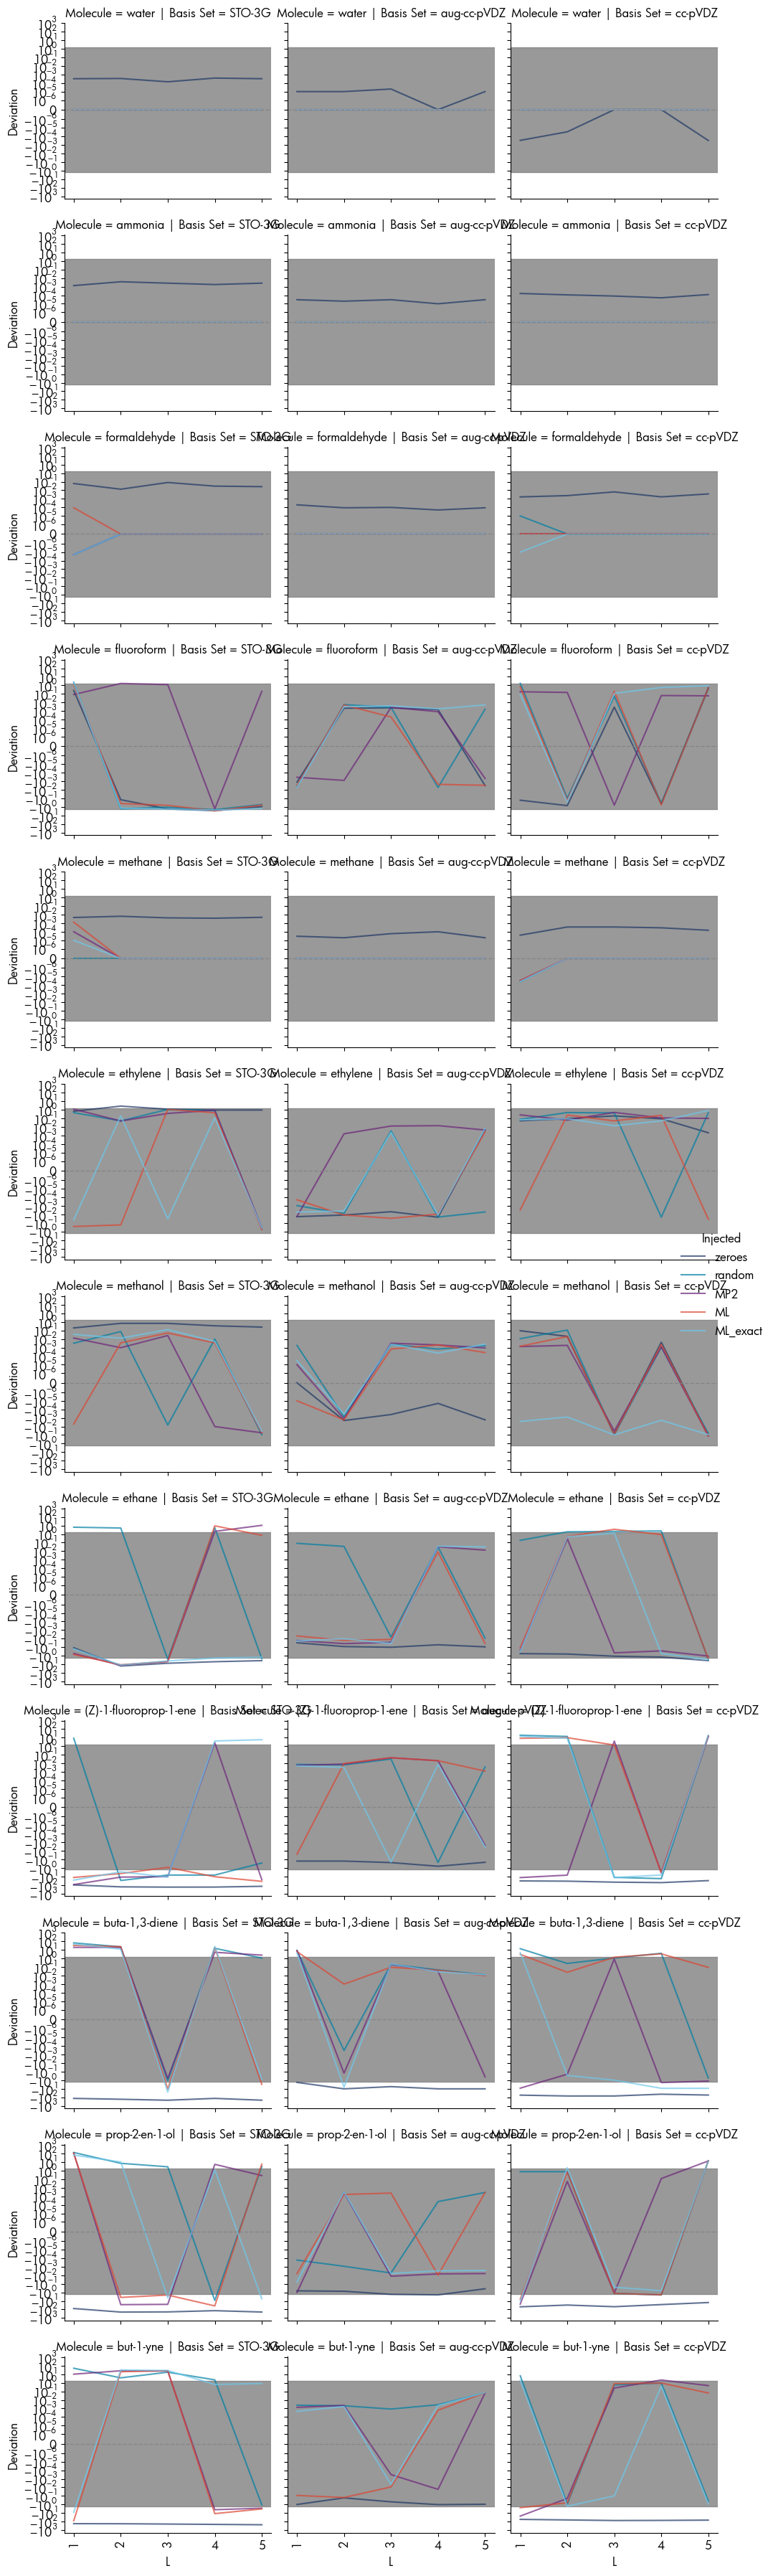

In [19]:


g = sns.FacetGrid(findDevCCSD.loc[findDevCCSD['Injected'] != 'CCSD'].sort_values(by=['Basis Set','n_atoms','L']), col="Basis Set",row='Molecule',hue="Injected",palette=palette,hue_order=['zeroes', 'random', 'MP2', 'ML', 'ML_exact'])
g.map(sns.lineplot, "L", "Deviation", alpha=.7)
g.add_legend()
for ax in g.axes.flat:
    ax.set_yscale("symlog", linthresh=1e-6)
    # ax.set_ylim(ymin - pad, ymax + pad)
    ax.axhline(0, color="gray", lw=1, ls="--", alpha=0.8)
    
    # # Gray fill region across same y-span
    # ax.fill_between(
    #     np.linspace(-0.5, len(LUCJDF["Method"].unique()) - 0.5, 100),
    #     -1.6, 1.6,
    #     color="gray", alpha=0.2
    # )
    ax.axhspan(-1.6, 1.6, color='gray', alpha=0.8, zorder=0)
    # ax.set_xlim(-0.5, len(LUCJDF["Method"].unique()) - 0.5)

    # Rotate and align x tick labels
    for label in ax.get_xticklabels():
        # print(label)
        label.set_rotation(90)
        label.set_horizontalalignment("center")
        label.set_verticalalignment("top")

g._legend.set_bbox_to_anchor((1.05, 0.5))
g._legend.set_frame_on(False)  
plt.tight_layout() 

/var/folders/px/qyhp9b8j4bb0z5wgydzgkpxw0000gn/T/ipykernel_13393/1632450452.py:1: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  g = sns.catplot(


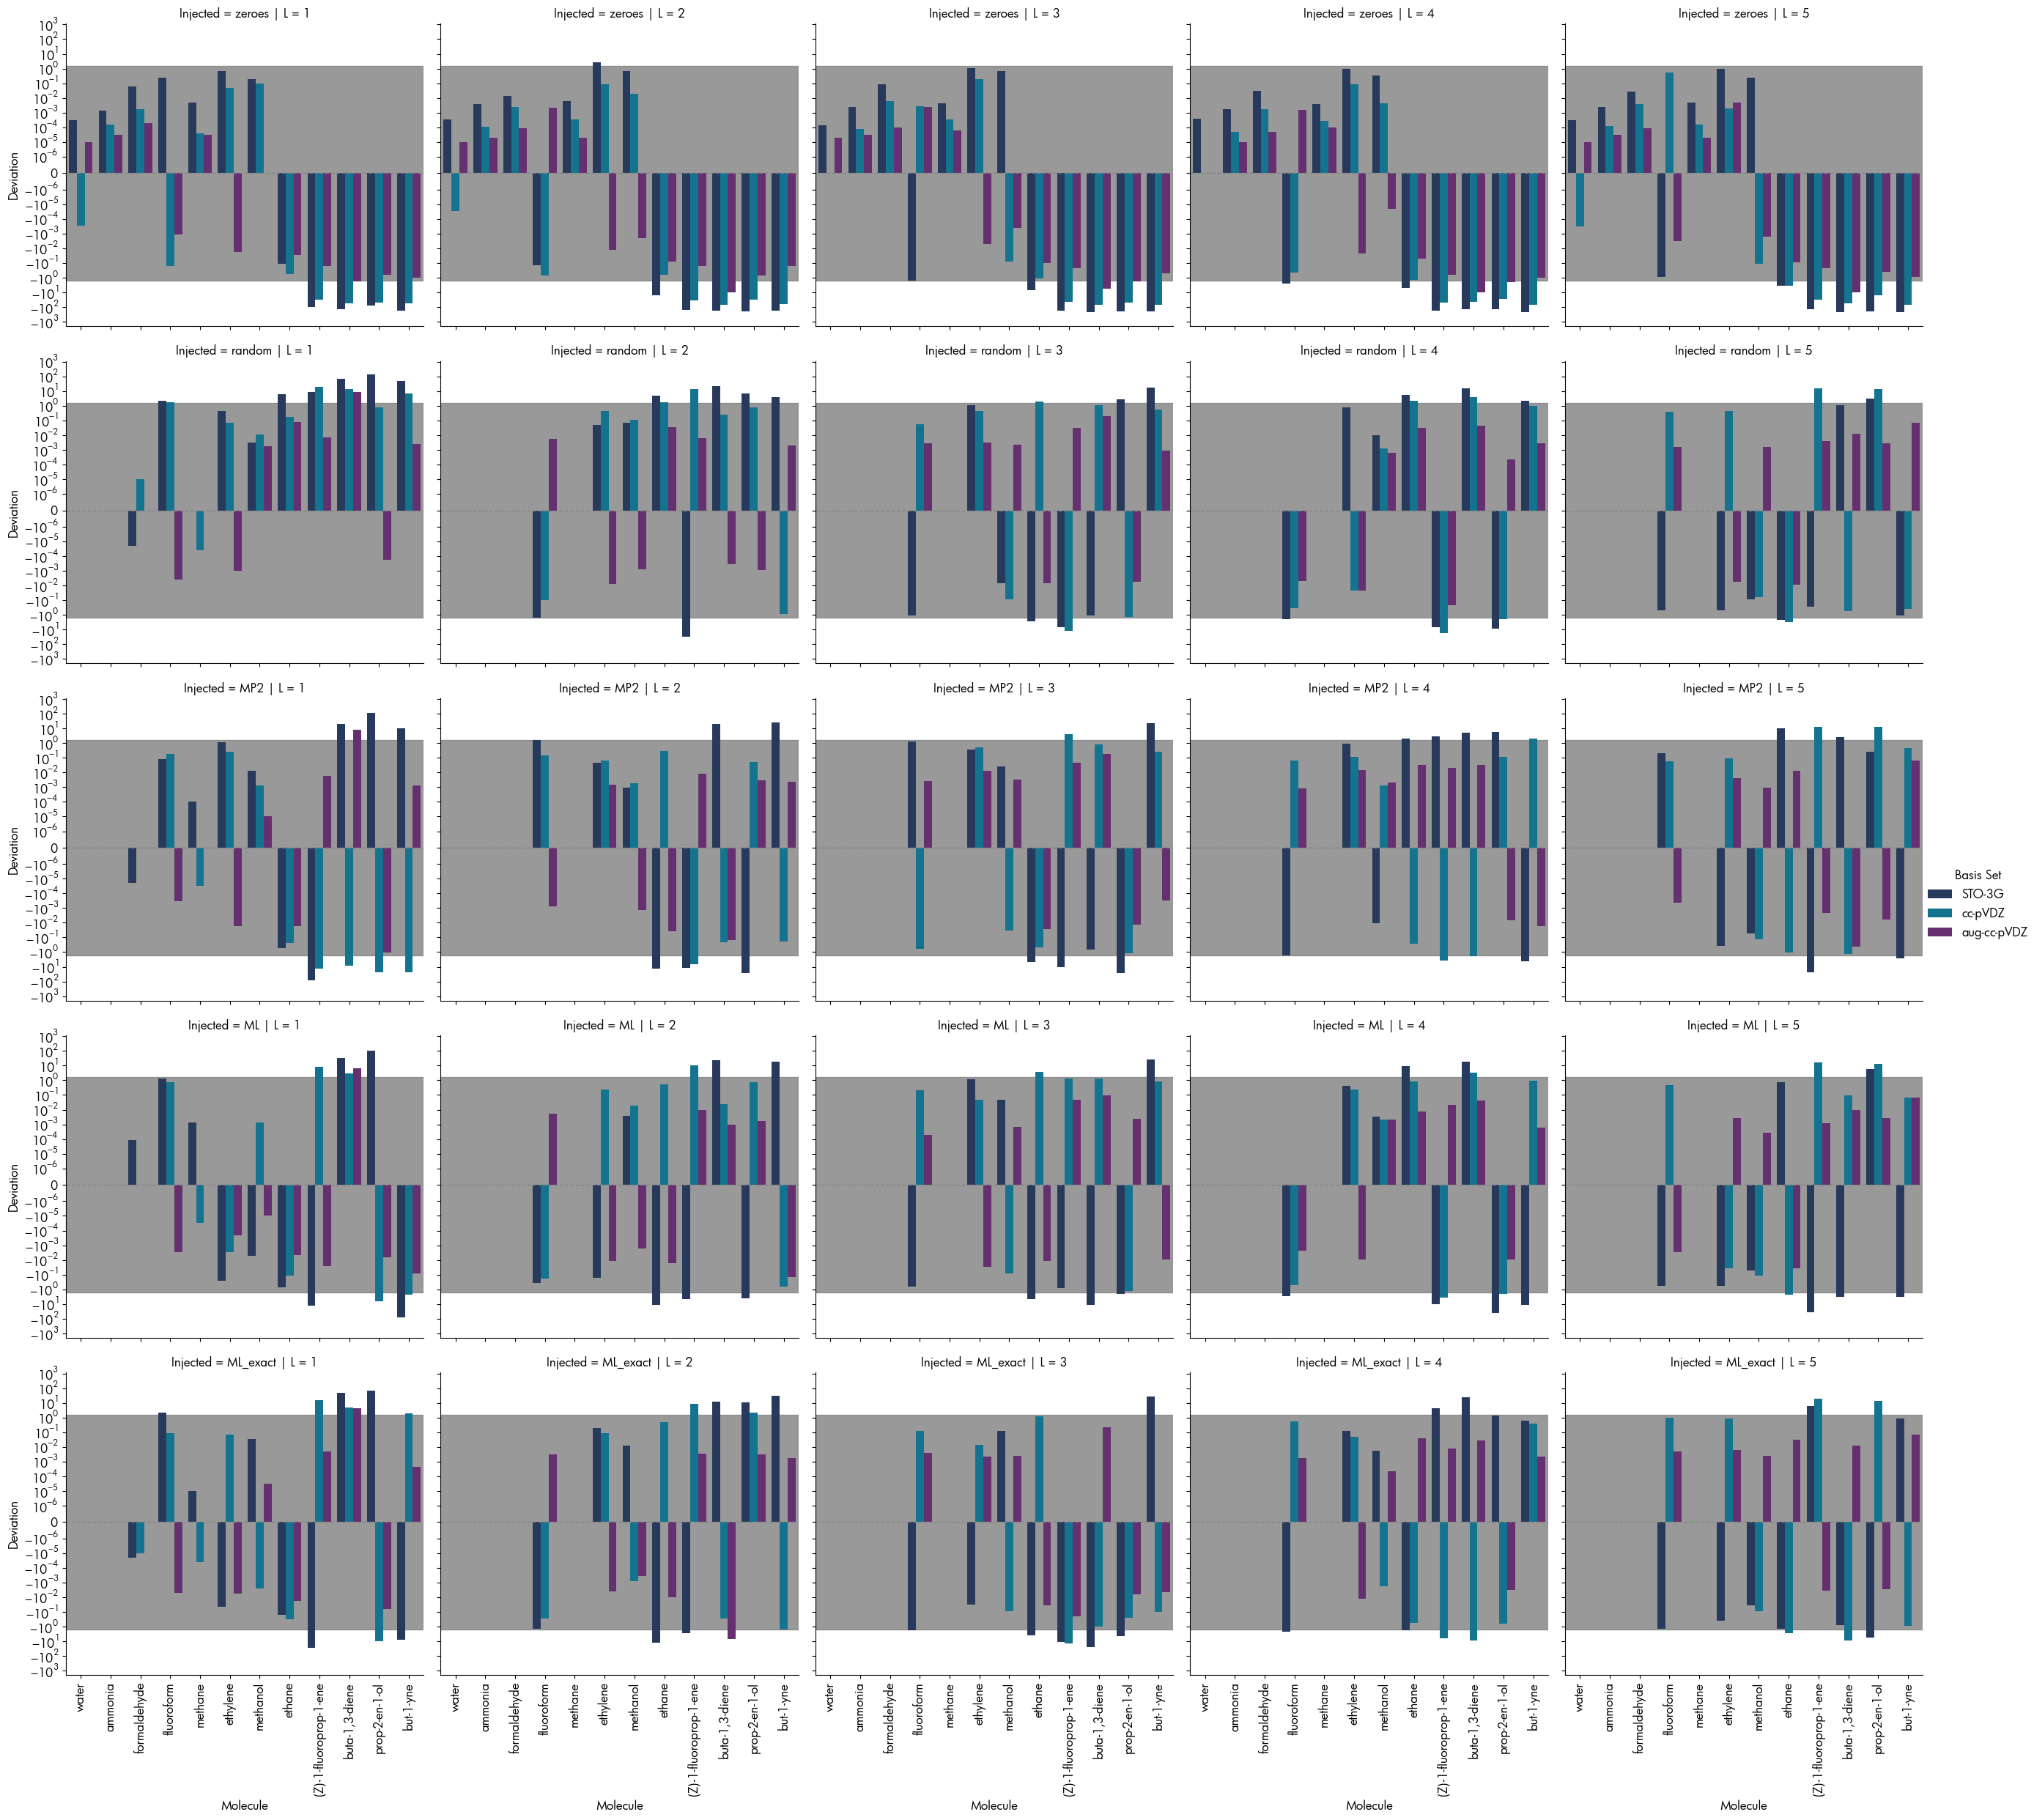

In [20]:


g = sns.catplot(
    data=findDevCCSD.loc[findDevCCSD['Injected'] != 'CCSD'].sort_values(by=['Basis Set','n_atoms','L']),
    hue='Basis Set',
    row='Injected',
    x='Molecule',
    y='Deviation',
    col='L',
    kind='bar',
    hue_order=['STO-3G','cc-pVDZ','aug-cc-pVDZ'],
    row_order=['zeroes', 'random', 'MP2', 'ML', 'ML_exact'],
    palette=palette
)

for ax in g.axes.flat:
    ax.set_yscale("symlog", linthresh=1e-6)
    # ax.set_ylim(ymin - pad, ymax + pad)
    ax.axhline(0, color="gray", lw=1, ls="--", alpha=0.8)
    
    # # Gray fill region across same y-span
    # ax.fill_between(
    #     np.linspace(-0.5, len(LUCJDF["Method"].unique()) - 0.5, 100),
    #     -1.6, 1.6,
    #     color="gray", alpha=0.2
    # )
    ax.axhspan(-1.6, 1.6, color='gray', alpha=0.8, zorder=0)
    # ax.set_xlim(-0.5, len(LUCJDF["Method"].unique()) - 0.5)

    # Rotate and align x tick labels
    for label in ax.get_xticklabels():
        # print(label)
        label.set_rotation(90)
        label.set_horizontalalignment("center")
        label.set_verticalalignment("top")

g._legend.set_bbox_to_anchor((1.05, 0.5))
g._legend.set_frame_on(False)  
plt.tight_layout()   
plt.savefig("./GMJ_figures/DevEnergiesCCSDInitAll.png",dpi=300,bbox_inches='tight')

/var/folders/px/qyhp9b8j4bb0z5wgydzgkpxw0000gn/T/ipykernel_13393/4024367732.py:1: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  g = sns.catplot(


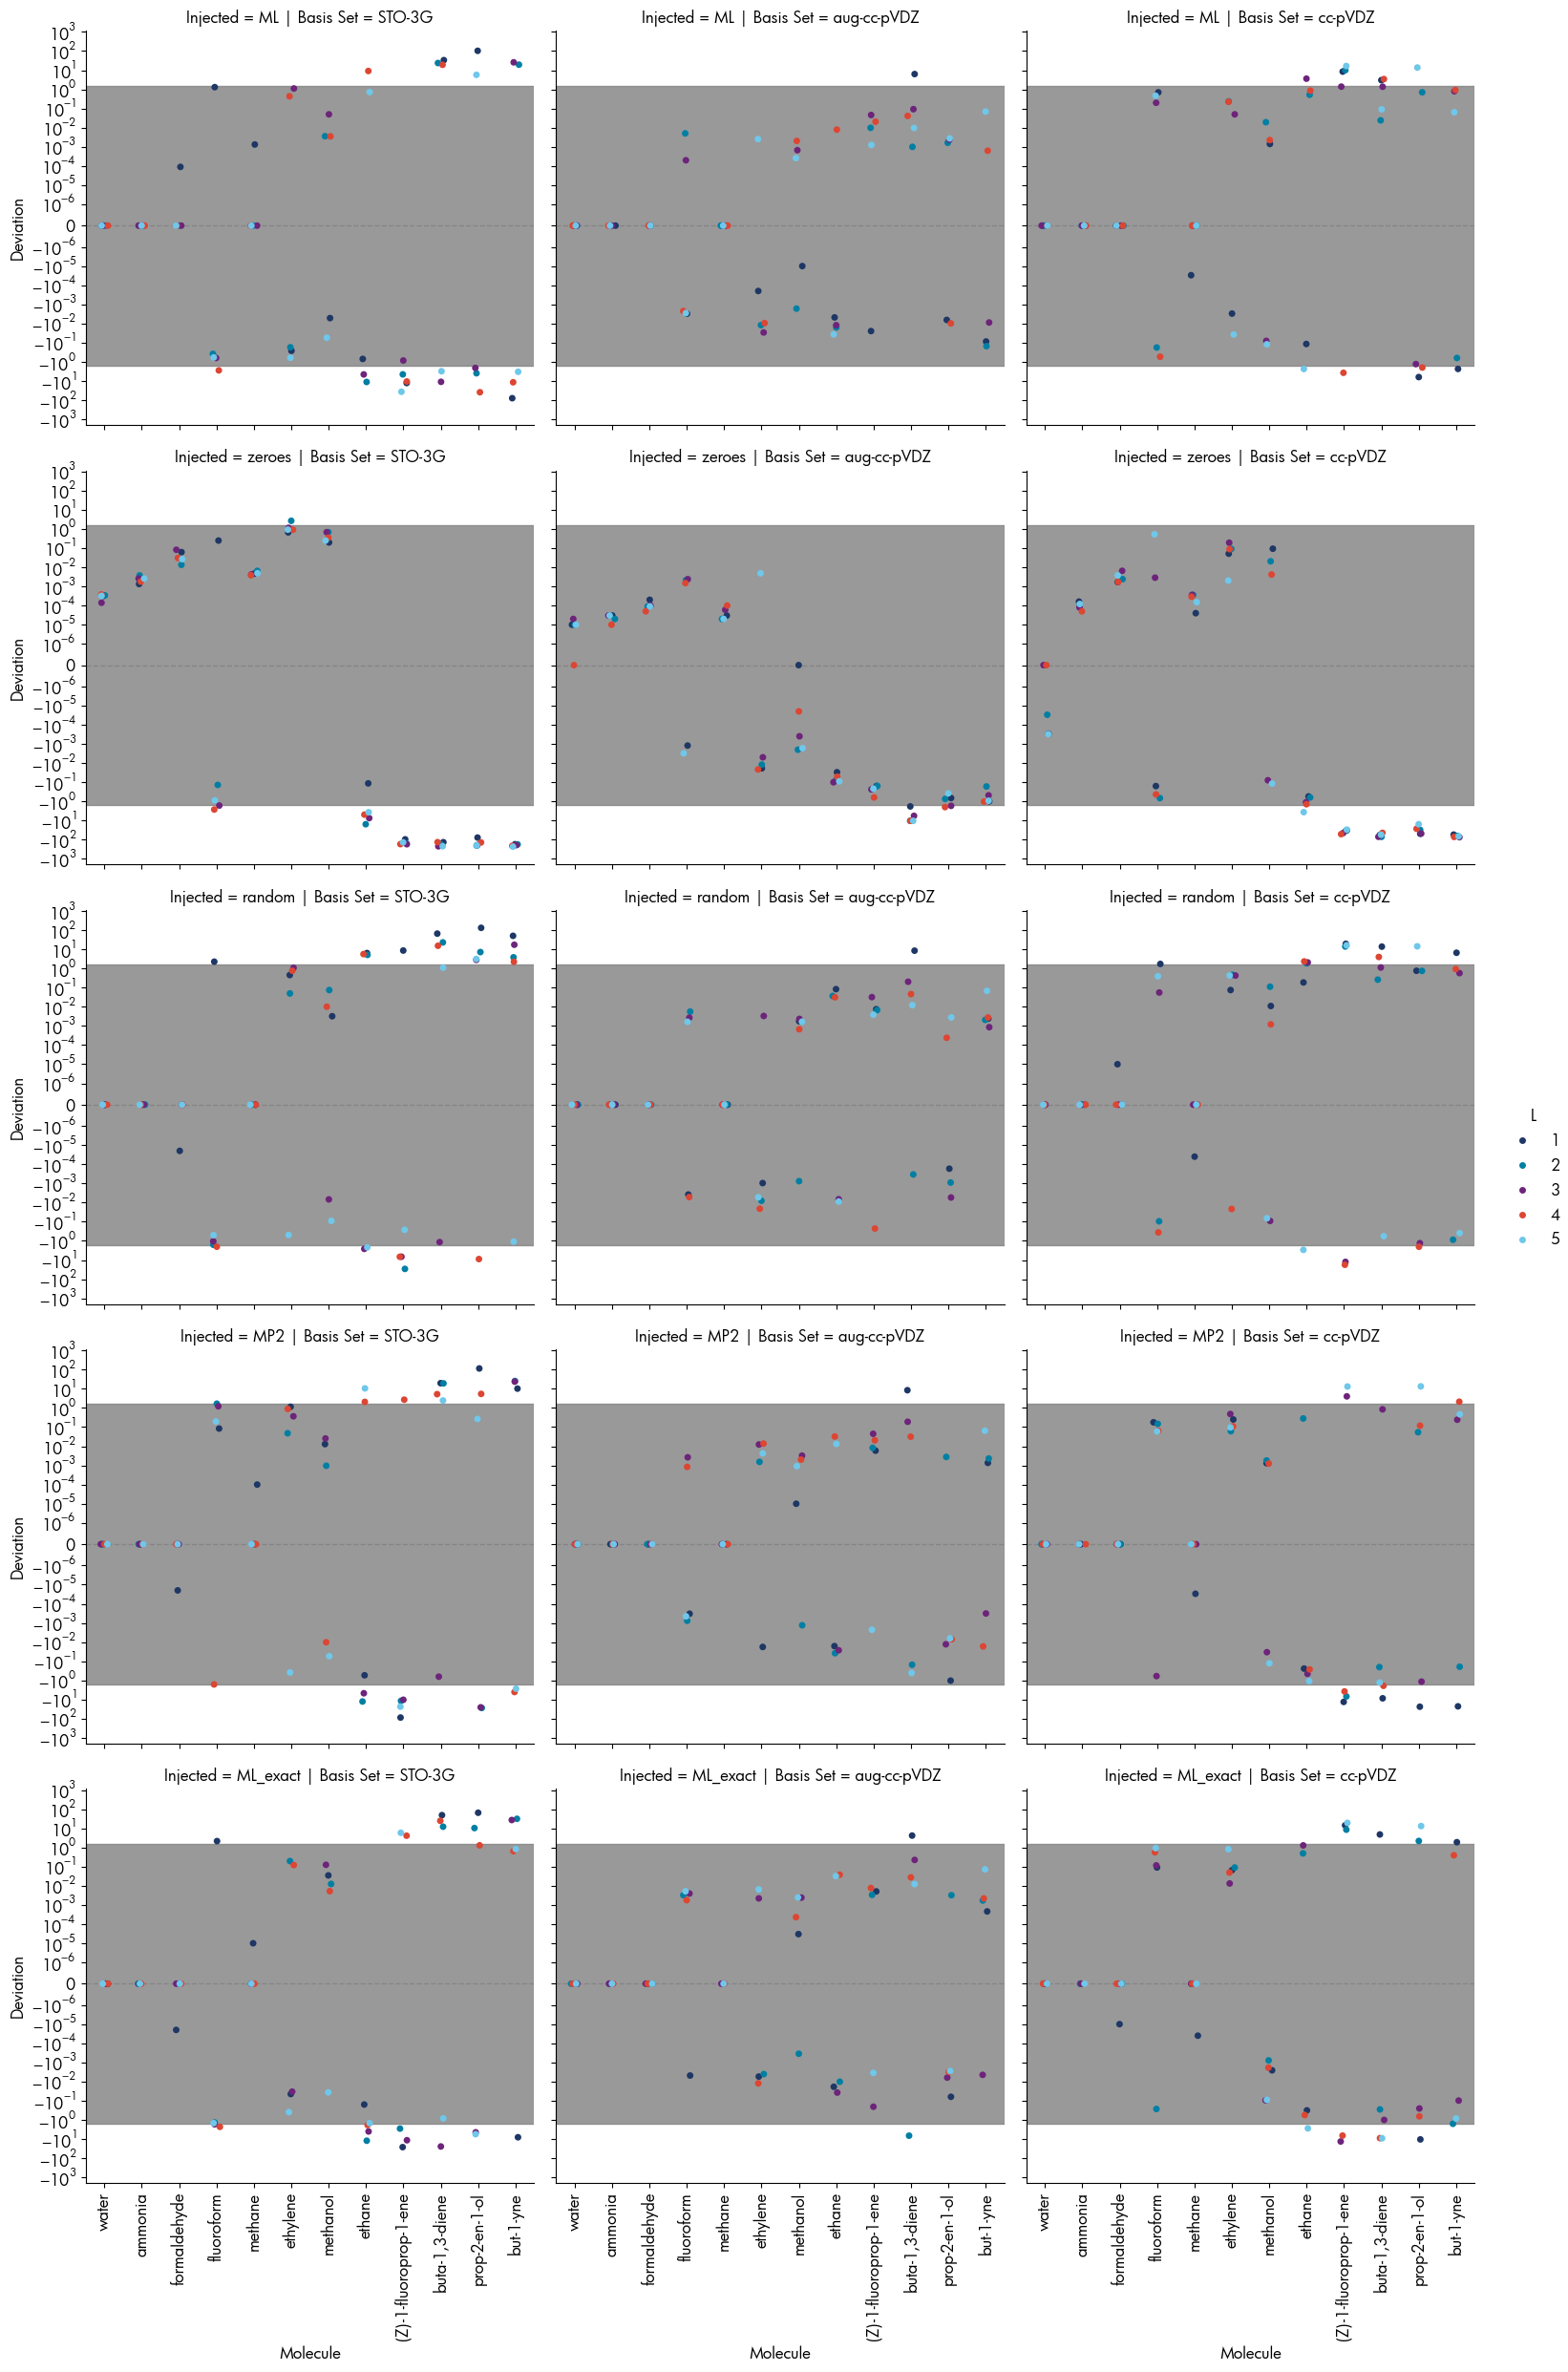

In [21]:
g = sns.catplot(
    data=findDevCCSD.loc[findDevCCSD['Injected'] != 'CCSD'].sort_values(by=['Basis Set','n_atoms','L']),
    col='Basis Set',
    row='Injected',
    x='Molecule',
    y='Deviation',
    hue='L',
    # kind='box',
    palette=palette
)
for ax in g.axes.flat:
    ax.set_yscale("symlog", linthresh=1e-6)
    # ax.set_ylim(ymin - pad, ymax + pad)
    ax.axhline(0, color="gray", lw=1, ls="--", alpha=0.8)
    
    # # Gray fill region across same y-span
    # ax.fill_between(
    #     np.linspace(-0.5, len(LUCJDF["Method"].unique()) - 0.5, 100),
    #     -1.6, 1.6,
    #     color="gray", alpha=0.2
    # )
    ax.axhspan(-1.6, 1.6, color='gray', alpha=0.8, zorder=0)
    # ax.set_xlim(-0.5, len(LUCJDF["Method"].unique()) - 0.5)

    # Rotate and align x tick labels
    for label in ax.get_xticklabels():
        # print(label)
        label.set_rotation(90)
        label.set_horizontalalignment("center")
        label.set_verticalalignment("top")

g._legend.set_bbox_to_anchor((1.05, 0.5))
g._legend.set_frame_on(False)  
plt.tight_layout()   

In [22]:
for inj, basis in product(['zeroes', 'random', 'MP2', 'ML', 'ML_exact'],uniqueBasis):
    devfind = findDevCCSD.loc[(findDevCCSD['Injected'] == inj)&(findDevCCSD['Basis Set'] == basis),'Deviation']
    print(inj,basis)
    print("min",findDevCCSD.loc[devfind.idxmin(),'Molecule'],f"{devfind.min():.2e}")
    print("max",findDevCCSD.loc[devfind.idxmax(),'Molecule'],f"{devfind.max():.2e}")
    print(devfind.describe().loc[['mean','min','max','std']].map('{:.2e}'.format))
    print(inj,basis,devfind[devfind.abs()>=1.6].shape[0])
    print()

zeroes STO-3G
min but-1-yne -2.31e+02
max ethylene 2.65e+00
mean    -5.73e+01
min     -2.31e+02
max      2.65e+00
std      8.40e+01
Name: Deviation, dtype: object
zeroes STO-3G 27

zeroes cc-pVDZ
min but-1-yne -7.39e+01
max fluoroform 5.22e-01
mean    -1.66e+01
min     -7.39e+01
max      5.22e-01
std      2.54e+01
Name: Deviation, dtype: object
zeroes cc-pVDZ 21

zeroes aug-cc-pVDZ
min buta-1,3-diene -1.03e+01
max ethylene 4.81e-03
mean    -8.23e-01
min     -1.03e+01
max      4.81e-03
std      2.35e+00
Name: Deviation, dtype: object
zeroes aug-cc-pVDZ 7

random STO-3G
min (Z)-1-fluoroprop-1-ene -2.89e+01
max prop-2-en-1-ol 1.32e+02
mean     4.81e+00
min     -2.89e+01
max      1.32e+02
std      2.06e+01
Name: Deviation, dtype: object
random STO-3G 24

random cc-pVDZ
min (Z)-1-fluoroprop-1-ene -1.76e+01
max (Z)-1-fluoroprop-1-ene 1.93e+01
mean     1.06e+00
min     -1.76e+01
max      1.93e+01
std      5.39e+00
Name: Deviation, dtype: object
random cc-pVDZ 15

random aug-cc-pVDZ
min (Z)-1-

In [23]:
layer_inj_dev = []
for inj, layers in product(['zeroes', 'random', 'MP2', 'ML', 'ML_exact'],sorted(uniqueLayers)):
    devfind = findDevCCSD.loc[(findDevCCSD['Injected'] == inj)&(findDevCCSD['L'] == layers),'Deviation']
    layer_inj_dev.append((inj,layers,(devfind[devfind.abs()<=1.6].shape[0]/devfind.shape[0])*1e2))
    # print()

In [24]:
mol_dev = []
for mol in uniqueMol:
    devfind = findDevCCSD.loc[(findDevCCSD['Molecule'] == mol),'Deviation']
    mol_dev.append((mol,(devfind[devfind.abs()<=1.6].shape[0]/devfind.shape[0])*1e2))
    # print()

moldevdf = pd.DataFrame(mol_dev).sort_values(by=[1])
moldevdf['n_atoms'] = moldevdf[0].map(n_atoms_dict)    
# moldevdf[[0,1]].to_clipboard()

In [25]:
for inj, mol in product(['zeroes', 'random', 'MP2', 'ML', 'ML_exact'],uniqueMol):
    devfind = findDevCCSD.loc[(findDevCCSD['Injected'] == inj)&(findDevCCSD['Molecule'] == mol),'Deviation']
    print(inj,mol,(devfind[devfind.abs()<=1.6].shape[0]/devfind.shape[0])*1e2)
    # print()

zeroes water 100.0
zeroes ammonia 100.0
zeroes formaldehyde 100.0
zeroes fluoroform 86.66666666666667
zeroes methane 100.0
zeroes ethylene 93.33333333333333
zeroes methanol 100.0
zeroes ethane 66.66666666666666
zeroes (Z)-1-fluoroprop-1-ene 33.33333333333333
zeroes but-1-yne 33.33333333333333
zeroes buta-1,3-diene 0.0
zeroes prop-2-en-1-ol 20.0
random water 100.0
random ammonia 100.0
random formaldehyde 100.0
random fluoroform 73.33333333333333
random methane 100.0
random ethylene 100.0
random methanol 100.0
random ethane 40.0
random (Z)-1-fluoroprop-1-ene 40.0
random but-1-yne 66.66666666666666
random buta-1,3-diene 60.0
random prop-2-en-1-ol 53.333333333333336
MP2 water 100.0
MP2 ammonia 100.0
MP2 formaldehyde 100.0
MP2 fluoroform 86.66666666666667
MP2 methane 100.0
MP2 ethylene 100.0
MP2 methanol 100.0
MP2 ethane 73.33333333333333
MP2 (Z)-1-fluoroprop-1-ene 33.33333333333333
MP2 but-1-yne 53.333333333333336
MP2 buta-1,3-diene 53.333333333333336
MP2 prop-2-en-1-ol 60.0
ML water 100.0

In [26]:
for inj, basis in product(['zeroes', 'random', 'MP2', 'ML', 'ML_exact'],uniqueBasis):
    devfind = findDevCCSD.loc[(findDevCCSD['Injected'] == inj)&(findDevCCSD['Basis Set'] == basis),'Deviation']
    print(inj,basis,(devfind[devfind.abs()<=1.6].shape[0]/devfind.shape[0])*1e2)
    # print()

zeroes STO-3G 55.00000000000001
zeroes cc-pVDZ 65.0
zeroes aug-cc-pVDZ 88.33333333333333
random STO-3G 60.0
random cc-pVDZ 75.0
random aug-cc-pVDZ 98.33333333333333
MP2 STO-3G 60.0
MP2 cc-pVDZ 81.66666666666667
MP2 aug-cc-pVDZ 98.33333333333333
ML STO-3G 61.66666666666667
ML cc-pVDZ 80.0
ML aug-cc-pVDZ 98.33333333333333
ML_exact STO-3G 63.33333333333333
ML_exact cc-pVDZ 78.33333333333333
ML_exact aug-cc-pVDZ 96.66666666666667


/var/folders/px/qyhp9b8j4bb0z5wgydzgkpxw0000gn/T/ipykernel_13393/1039327296.py:2: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  g = sns.catplot(


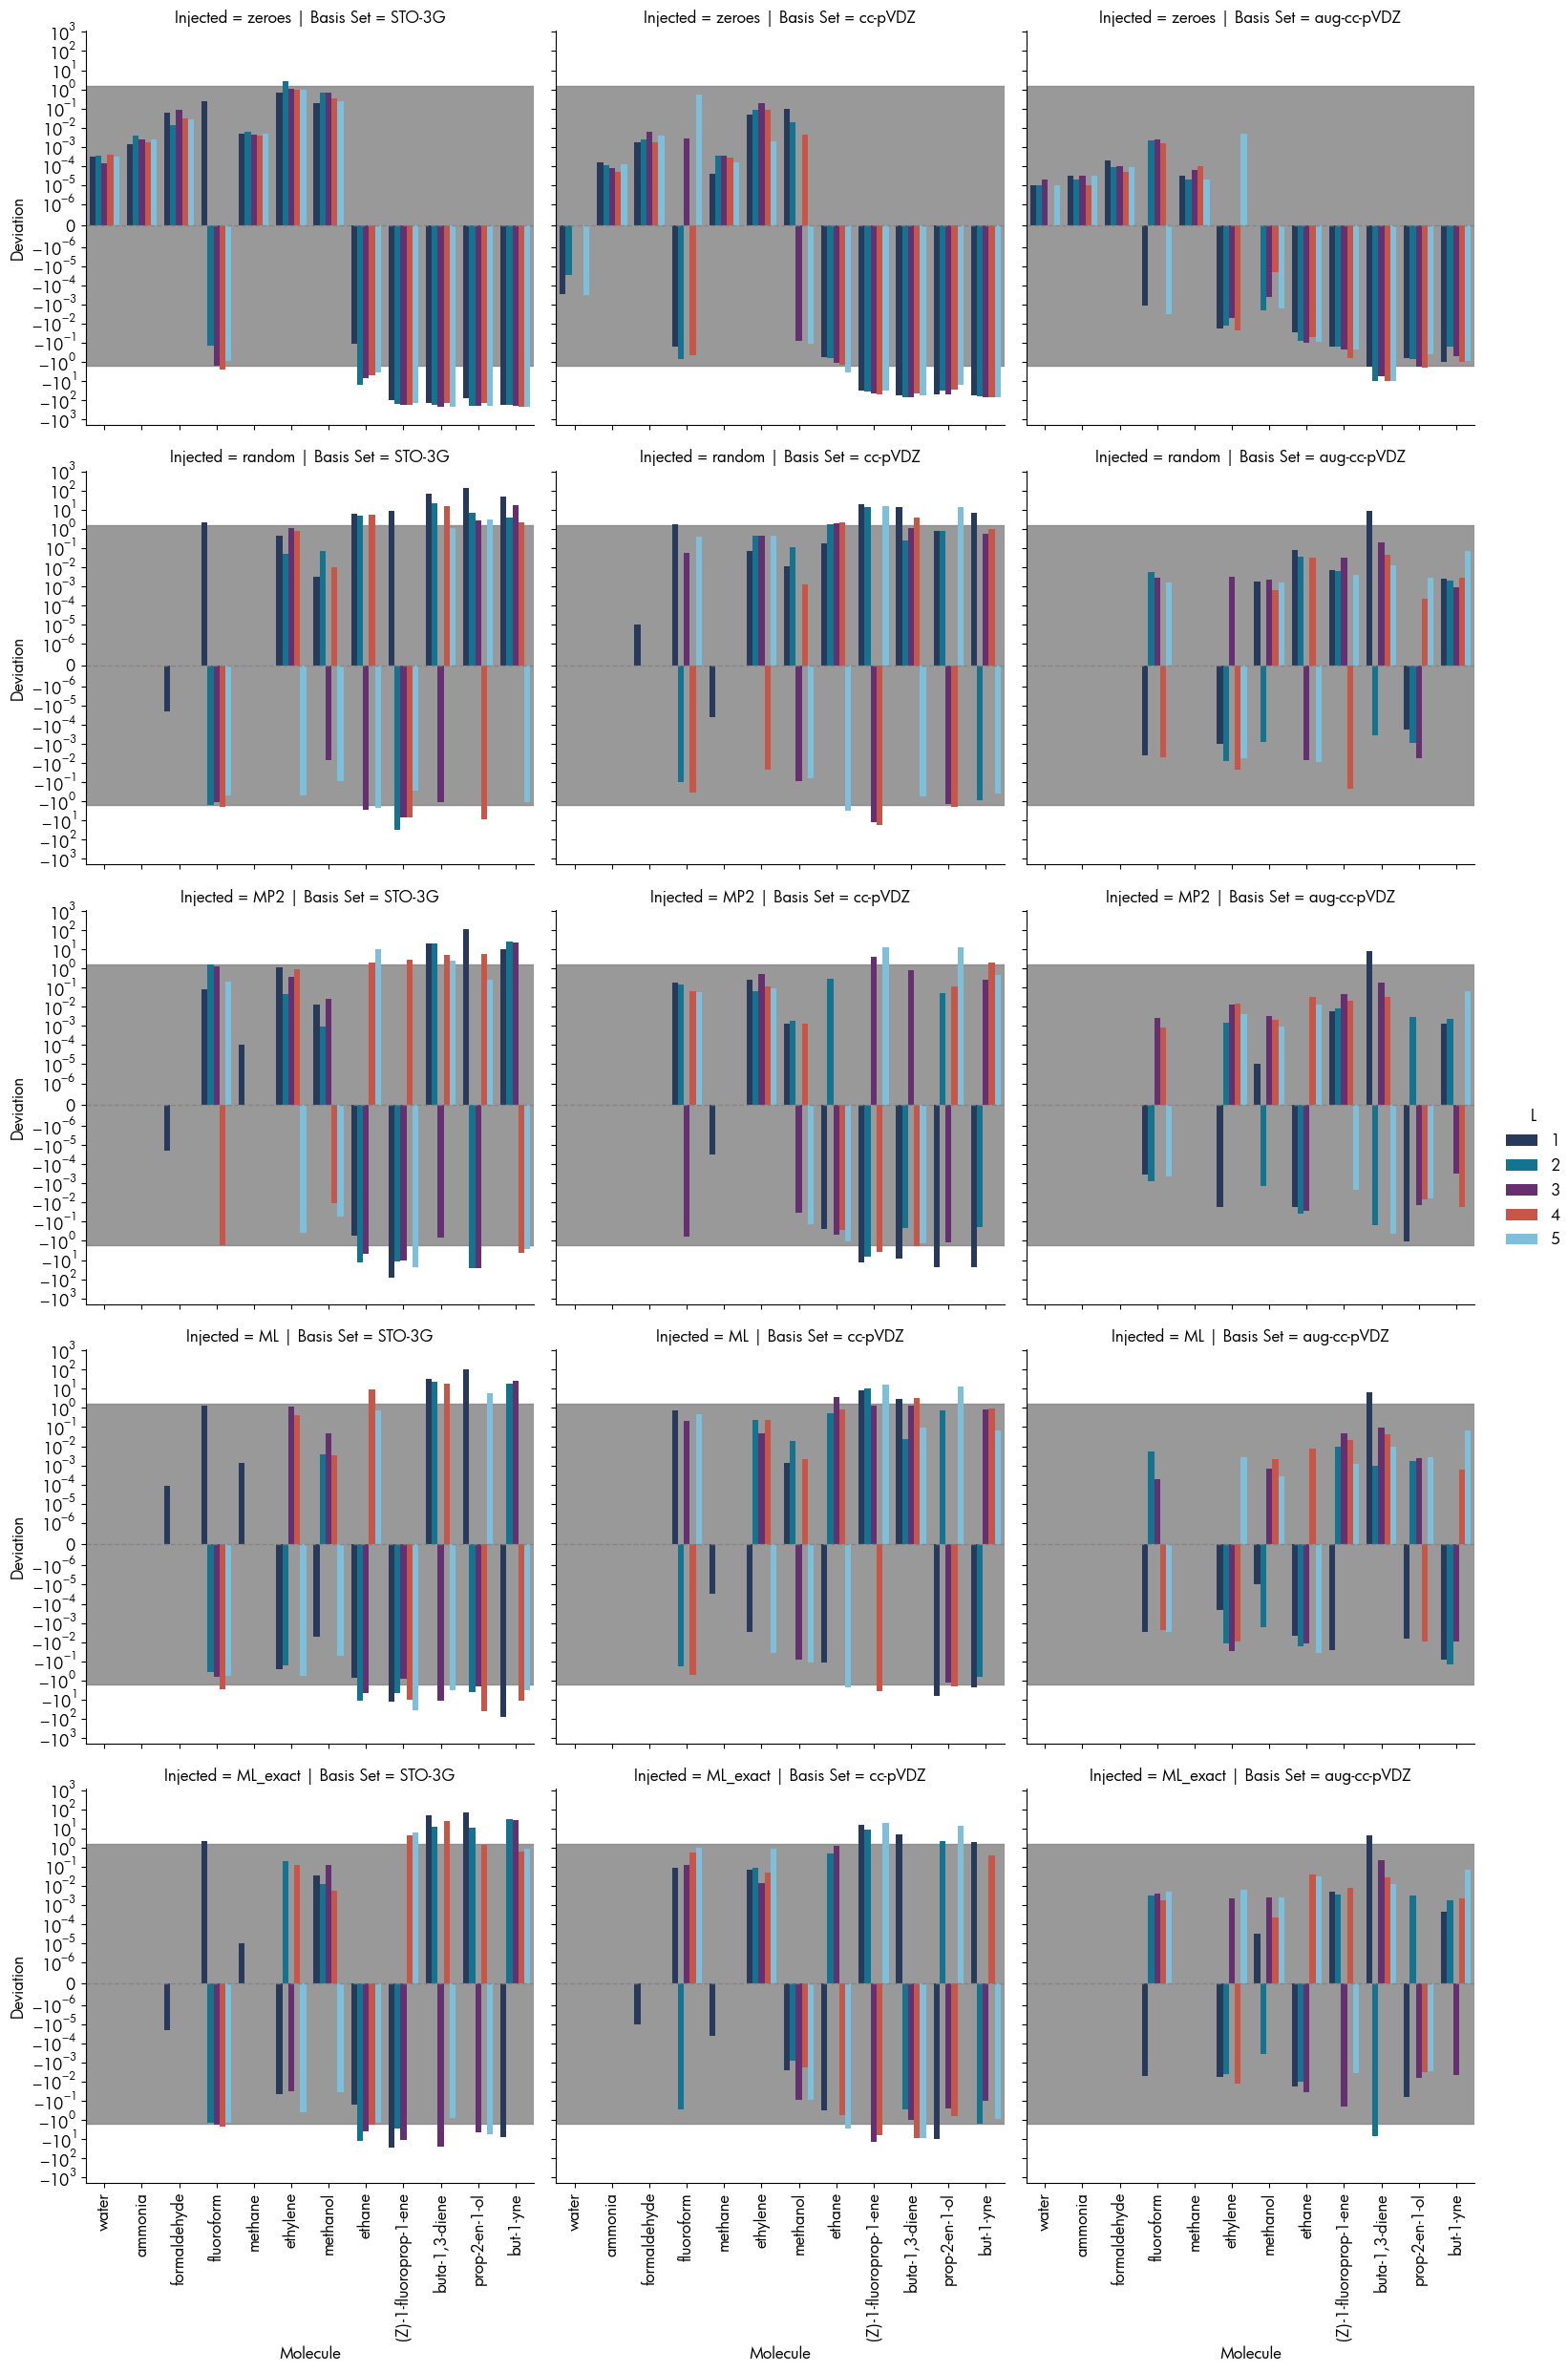

In [27]:
# 1. Generate your catplot and store it in a variable (g)
g = sns.catplot(
    data=findDevCCSD.loc[findDevCCSD['Injected'] != 'CCSD'].sort_values(by=['Basis Set','n_atoms','L']),
    col='Basis Set',
    row='Injected',
    x='Molecule',
    y='Deviation',
    hue='L',
    kind='bar',
    row_order=['zeroes','random','MP2','ML','ML_exact'],
    col_order=['STO-3G','cc-pVDZ','aug-cc-pVDZ'],
    palette=palette
)
for ax in g.axes.flat:
    ax.set_yscale("symlog", linthresh=1e-6)
    # ax.set_ylim(ymin - pad, ymax + pad)
    ax.axhline(0, color="gray", lw=1, ls="--", alpha=0.8)
    
    # # Gray fill region across same y-span
    # ax.fill_between(
    #     np.linspace(-0.5, len(LUCJDF["Method"].unique()) - 0.5, 100),
    #     -1.6, 1.6,
    #     color="gray", alpha=0.2
    # )
    ax.axhspan(-1.6, 1.6, color='gray', alpha=0.8, zorder=0)
    # ax.set_xlim(-0.5, len(LUCJDF["Method"].unique()) - 0.5)

    # Rotate and align x tick labels
    for label in ax.get_xticklabels():
        # print(label)
        label.set_rotation(90)
        label.set_horizontalalignment("center")
        label.set_verticalalignment("top")

g._legend.set_bbox_to_anchor((1.05, 0.5))
g._legend.set_frame_on(False)  
plt.tight_layout()   
# # 2. Define a helper function to apply the gray span and axis scaling to each facet
# def customize_facet(*args, **kwargs):
#     ax = plt.gca()
#     # Add the gray area for chemical accuracy (~1 kcal/mol or 1.6 mHa depending on your units)
#     ax.axhspan(-1.6, 1.6, color='gray', alpha=0.3, zorder=0) # Lowered alpha to 0.3 so bars remain visible
    
#     # Apply symlog scaling and limits
#     ax.set_yscale("symlog", linthresh=1e-12)
#     ax.set_ylim(-1e3, 1e3)

# # 3. Map the custom function across all subplots in the FacetGrid
# g.map_dataframe(customize_facet)
plt.savefig("./GMJ_figures/DevEnergiesCCSDInitAll.png",dpi=300,bbox_inches='tight')
# Display the plot
plt.show()

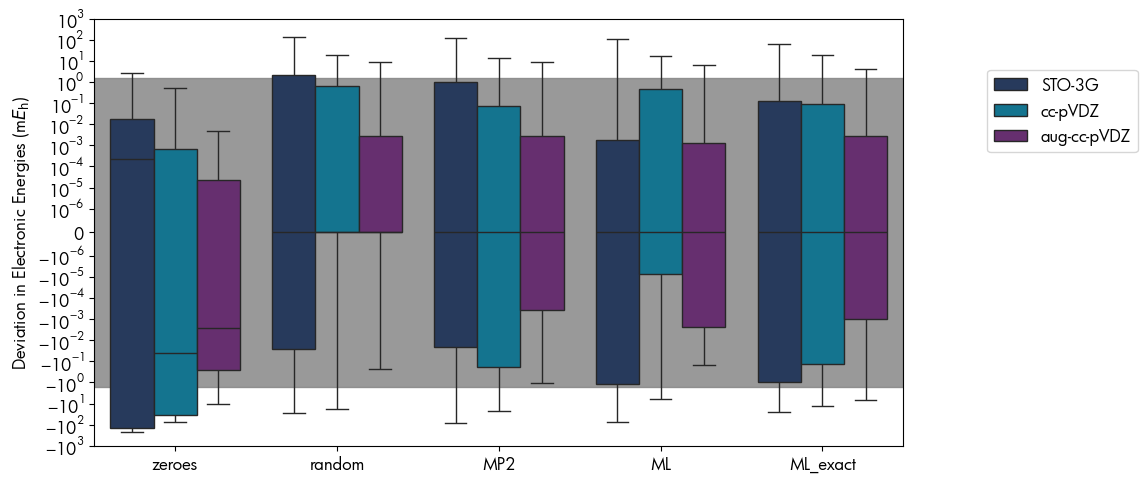

In [28]:

plt.figure(figsize=(12,5))
sns.boxplot(findDevCCSD,x='Injected',y='Deviation',hue='Basis Set',hue_order=['STO-3G','cc-pVDZ','aug-cc-pVDZ'],palette=palette[0:3],order=['zeroes','random','MP2','ML','ML_exact'],whis=(0, 100))
plt.axhspan(-1.6, 1.6, color='gray', alpha=0.8, zorder=0)
plt.yscale("symlog",linthresh=1e-6)
plt.ylim(-1e3,1e3)
plt.xlabel("")
plt.ylabel(r"Deviation in Electronic Energies (m$E_{\mathrm{h}}$)")
plt.legend(bbox_to_anchor=(1.3, 0.9))
plt.tight_layout()
plt.savefig("./GMJ_figures/DevEnergiesCCSDInit.png",dpi=300,bbox_inches='tight')
plt.show()

In [29]:
for inj in uniqueInj:
    for basis in uniqueBasis:
        devdf = findDevCCSD.loc[(findDevCCSD['Injected'] == inj)&(findDevCCSD['Basis Set']==basis),'Deviation']
        print(inj)
        print(devdf.describe().loc[['mean','min','max','std']].map('{:.2e}'.format))
        print(devdf.idxmin(),findDevCCSD.loc[findDevCCSD['Injected'] == inj].loc[devdf.idxmin()])

zeroes
mean    -5.73e+01
min     -2.31e+02
max      2.65e+00
std      8.40e+01
Name: Deviation, dtype: object
9 Basis Set        STO-3G
Molecule      but-1-yne
L                     5
Injected         zeroes
Energy      -153.259322
n_atoms              10
Deviation    -231.16019
Name: 9, dtype: object
zeroes
mean    -1.66e+01
min     -7.39e+01
max      5.22e-01
std      2.54e+01
Name: Deviation, dtype: object
507 Basis Set       cc-pVDZ
Molecule      but-1-yne
L                     3
Injected         zeroes
Energy      -154.986102
n_atoms              10
Deviation     -73.86788
Name: 507, dtype: object
zeroes
mean    -8.23e-01
min     -1.03e+01
max      4.81e-03
std      2.35e+00
Name: Deviation, dtype: object
146 Basis Set       aug-cc-pVDZ
Molecule     buta-1,3-diene
L                         2
Injected             zeroes
Energy          -154.950256
n_atoms                  10
Deviation         -10.34143
Name: 146, dtype: object
random
mean     4.81e+00
min     -2.89e+01
max      1.3

In [30]:
meltedLUCJ = LUCJDF.melt(id_vars=['Basis Set', 'Molecule','L', 'Injected'],value_vars=['Energy', 'Energy (HCI)', 'Energy (HF)', 'Energy (CASCI)'],var_name='Methods',value_name='Energies')

<Axes: >

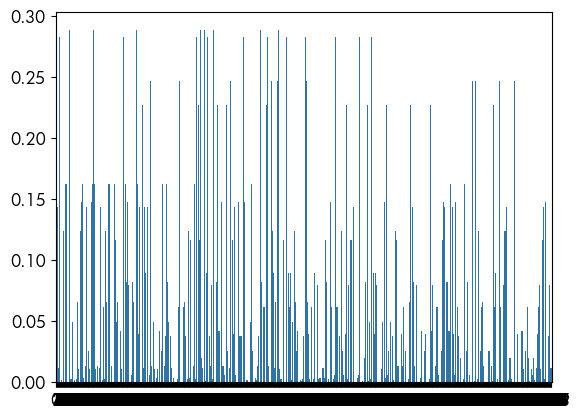

In [31]:
sns.barplot(LUCJDF["Energy (HF)"]-LUCJDF["Energy (HCI)"])

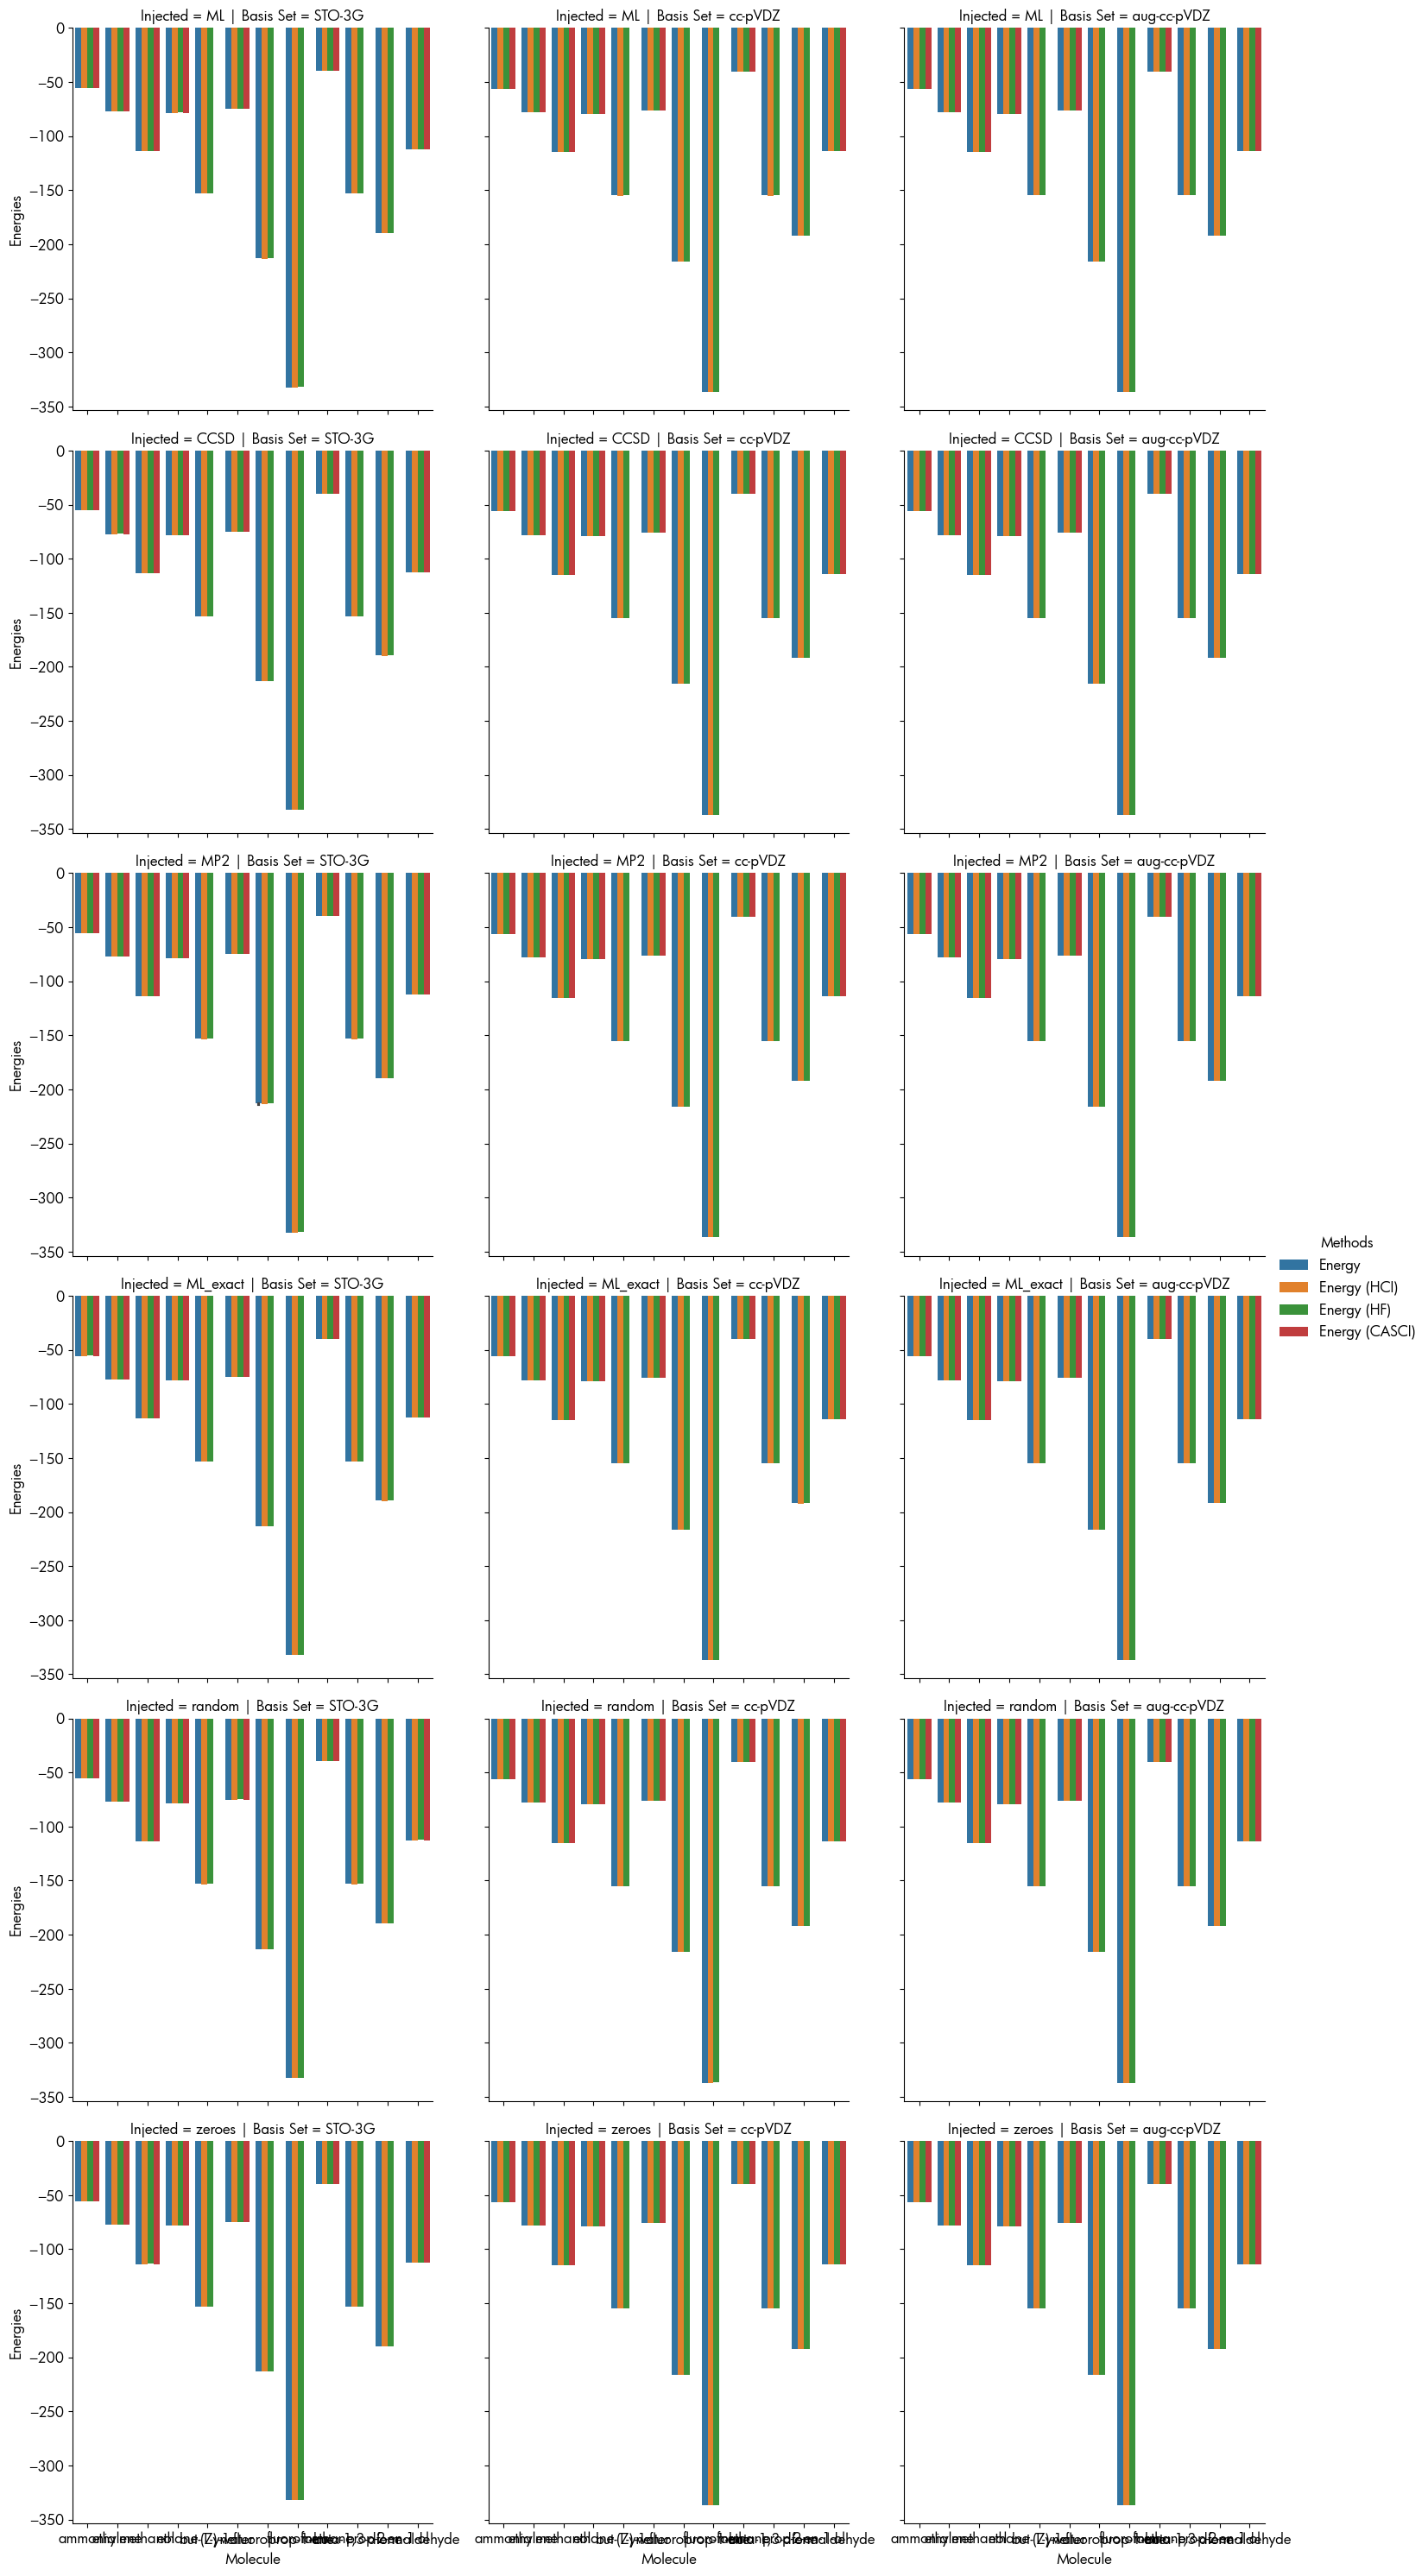

In [32]:
sns.catplot(meltedLUCJ,col='Basis Set',row='Injected',x='Molecule',y='Energies',hue='Methods',kind='bar')

In [33]:
for i in new:
    name, method, layers, basis, injection = os.path.basename(i).replace('.txt','').split("_",4)
    layers = int(layers.strip('L'))
    mask = (LUCJDF['Basis Set'] == basis) & (LUCJDF['Molecule'] == name) & (LUCJDF['L'] == layers) & (LUCJDF['Injected'] == injection)
    print((LUCJDF.loc[mask,'Energy'].values-LUCJDF.loc[mask,'Energy (HCI)'].values) * 1e3,LUCJDF.loc[mask,'Deviation'].values)

[-0.03492465] [-0.03492465]
[-0.01999912] [-0.01999912]
[-0.0010849] [-0.0010849]
[-0.51920346] [-0.51920346]
[-1.15093207] [-1.15093207]
[2.01805164] [2.01805164]
[-0.01999912] [-0.01999912]
[-0.17887185] [-0.17887185]
[278.8406921] [278.8406921]
[48.7796821] [48.7796821]
[-0.02477509] [-0.02477509]
[1.40396793] [1.40396793]
[1.15376575] [1.15376575]
[-0.00058911] [-0.00058911]
[202.71358985] [202.71358985]
[-0.02519904] [-0.02519904]
[-0.00224482] [-0.00224482]
[-0.96738993] [-0.96738993]
[-0.0137484] [-0.0137484]
[0.1057816] [0.1057816]
[0.0592516] [0.0592516]
[-0.21569656] [-0.21569656]
[-0.01999912] [-0.01999912]
[-0.00630656] [-0.00630656]
[-0.99735942] [-0.99735942]
[-0.52250346] [-0.52250346]
[-0.0063684] [-0.0063684]
[285.7290818] [285.7290818]
[-0.71150656] [-0.71150656]
[0.70914153] [0.70914153]
[66.0011218] [66.0011218]
[87.25011424] [87.25011424]
[0.42274548] [0.42274548]
[0.15526575] [0.15526575]
[2.12803548] [2.12803548]
[1.15292575] [1.15292575]
[-0.00029247] [-0.000292

In [34]:
# 1. Individual dictionaries for each level (summary stats)
basis_mae = {}
mol_mae = {}
inj_mae = {}
layer_mae = {}

# 2. The master compiled dictionary (nested)
all_mae = {}

for basis in uniqueBasis:
    b_mask = (LUCJDF['Basis Set'] == basis)
    basis_mae[basis] = mean_absolute_error(LUCJDF.loc[b_mask, 'Energy'], LUCJDF.loc[b_mask, 'Energy (HCI)']) * 1e3
    
    all_mae[basis] = {} # Initialize next level
    
    for mol in uniqueMol:
        m_mask = (LUCJDF['Molecule'] == mol)
        # Unique dict for molecules (could use a tuple key to keep it unique across basis sets)
        mol_mae[(basis, mol)] = mean_absolute_error(LUCJDF.loc[b_mask & m_mask, 'Energy'], LUCJDF.loc[b_mask & m_mask, 'Energy (HCI)']) * 1e3
        
        all_mae[basis][mol] = {}
        
        for inj in uniqueInj:
            i_mask = (LUCJDF['Injected'] == inj)
            inj_mae[(basis, mol, inj)] = mean_absolute_error(LUCJDF.loc[b_mask & m_mask & i_mask, 'Energy'], LUCJDF.loc[b_mask & m_mask & i_mask, 'Energy (HCI)']) * 1e3
            
            all_mae[basis][mol][inj] = {}
            
            for L in uniqueLayers:
                l_mask = (LUCJDF['L'] == L)
                
                # Check to avoid errors if a specific slice is empty
                subset = LUCJDF.loc[b_mask & m_mask & i_mask & l_mask]
                if not subset.empty:
                    mae_val = mean_absolute_error(subset['Energy'], subset['Energy (HCI)']) * 1e3
                    
                    # Store in unique flat dict
                    layer_mae[(basis, mol, inj, L)] = mae_val
                    
                    # Store in the compiled nested dict
                    all_mae[basis][mol][inj][L] = mae_val

# 1. Basis MAE (Keys are single strings)
basis_mae_df = pd.DataFrame(list(basis_mae.items()), 
                            columns=['Basis', 'MAE'])

# 2. Molecule MAE (Keys are tuples: (basis, mol))
mol_mae_df = pd.DataFrame([(*k, v) for k, v in mol_mae.items()], 
                          columns=['Basis', 'Molecule', 'MAE'])

# 3. Injected MAE (Keys are tuples: (basis, mol, inj))
inj_mae_df = pd.DataFrame([(*k, v) for k, v in inj_mae.items()], 
                          columns=['Basis', 'Molecule', 'Injected', 'MAE'])

# 4. Layer MAE (Keys are tuples: (basis, mol, inj, L))
layer_mae_df = pd.DataFrame([(*k, v) for k, v in layer_mae.items()], 
                            columns=['Basis', 'Molecule', 'Injected', 'L', 'MAE'])                    

/var/folders/px/qyhp9b8j4bb0z5wgydzgkpxw0000gn/T/ipykernel_13393/2530434211.py:1: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  g = sns.catplot(data=layer_mae_df,x='Molecule',y='MAE',hue='Basis',col='Injected',kind='bar',row='L',col_order=['zeroes','random','MP2','ML','ML_exact','CCSD'],palette=palette)


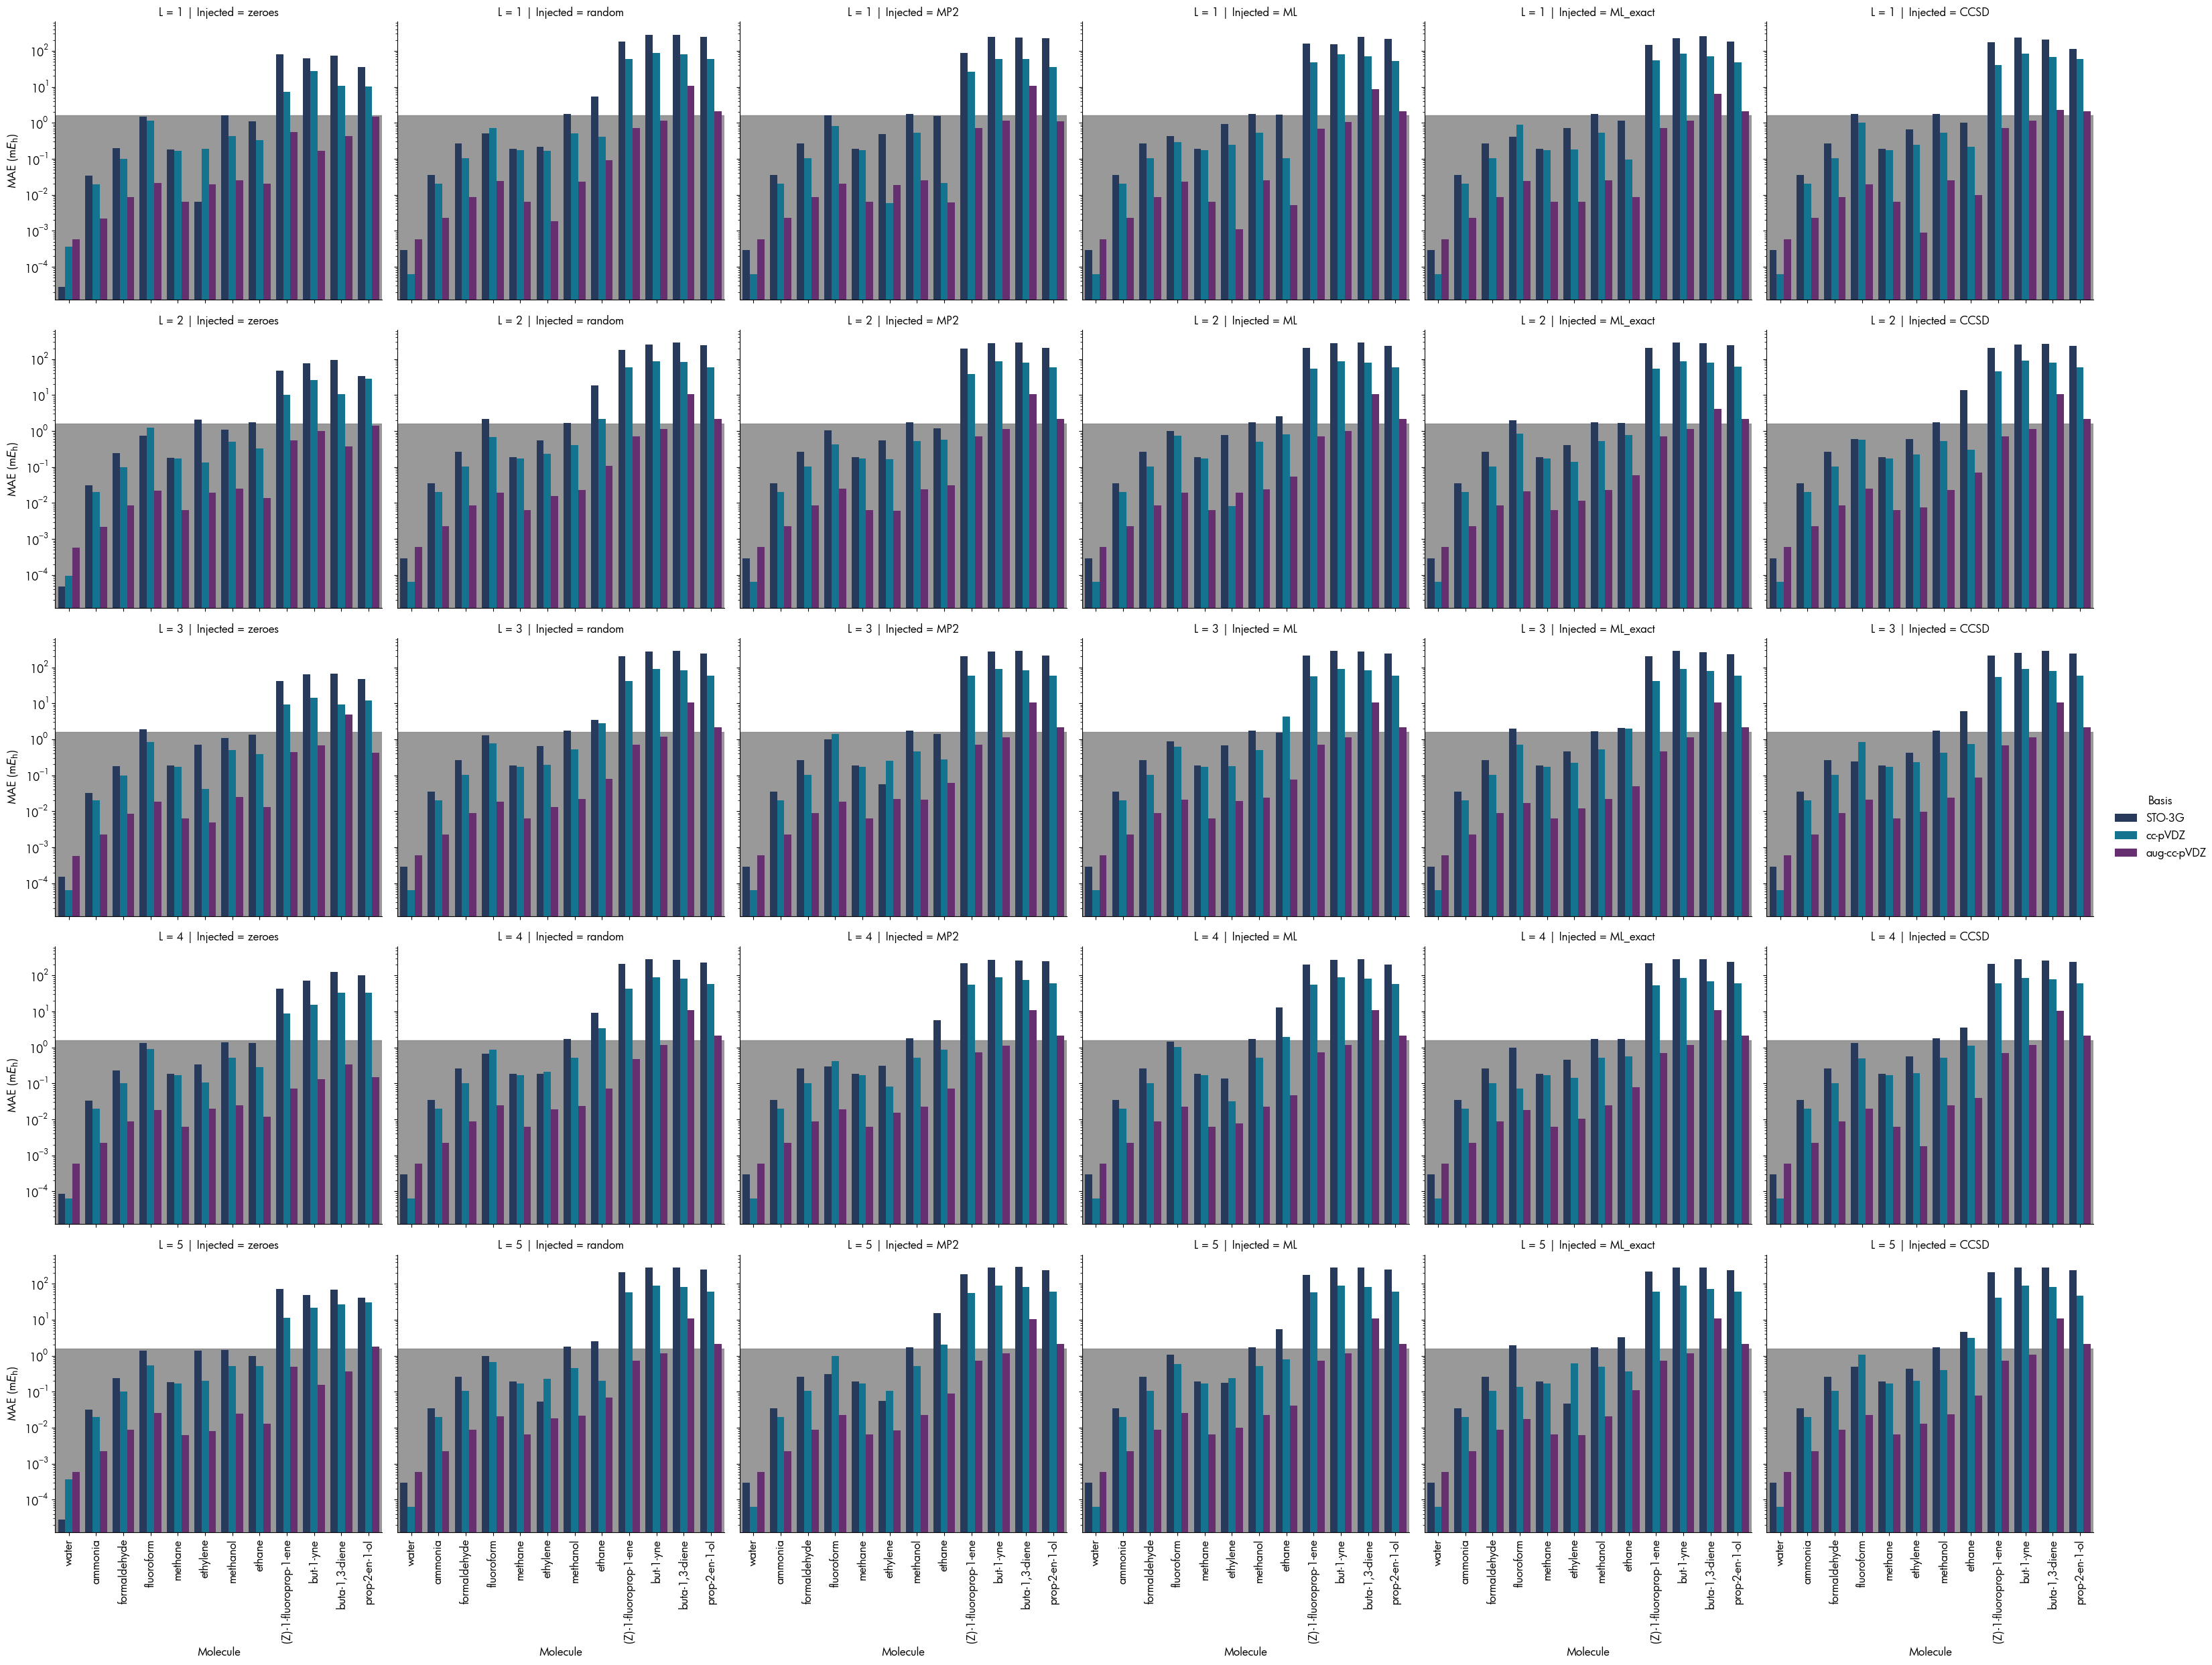

In [35]:
g = sns.catplot(data=layer_mae_df,x='Molecule',y='MAE',hue='Basis',col='Injected',kind='bar',row='L',col_order=['zeroes','random','MP2','ML','ML_exact','CCSD'],palette=palette)
for ax in g.axes.flat:
    ax.set_yscale("log")
    # ax.set_ylim(ymin - pad, ymax + pad)
    ax.axhline(0, color="gray", lw=1, ls="--", alpha=0.8)
    ax.set_ylabel(r"MAE (m$E_{\mathrm{h}}$)")
    # # Gray fill region across same y-span
    # ax.fill_between(
    #     np.linspace(-0.5, len(LUCJDF["Method"].unique()) - 0.5, 100),
    #     -1.6, 1.6,
    #     color="gray", alpha=0.2
    # )
    ax.axhspan(-1.6, 1.6, color='gray', alpha=0.8, zorder=0)
    # ax.set_xlim(-0.5, len(LUCJDF["Method"].unique()) - 0.5)

    # Rotate and align x tick labels
    for label in ax.get_xticklabels():
        # print(label)
        label.set_rotation(90)
        label.set_horizontalalignment("center")
        label.set_verticalalignment("top")
g._legend.set_bbox_to_anchor((1.05, 0.5))
g._legend.set_frame_on(False)        
# plt.legend(loc='center right', bbox_to_anchor=(1.5, 0.5))        
plt.tight_layout()        
plt.savefig("GMJ_figures/MAE_inj_mol_basis_layer.png",dpi=300,bbox_inches='tight')

/var/folders/px/qyhp9b8j4bb0z5wgydzgkpxw0000gn/T/ipykernel_13393/1137384109.py:1: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  g = sns.catplot(data=inj_mae_df,x='Molecule',y='MAE',hue='Basis',col='Injected',kind='bar',col_order=['zeroes','random','MP2','ML','ML_exact','CCSD'],palette=palette,col_wrap=3)


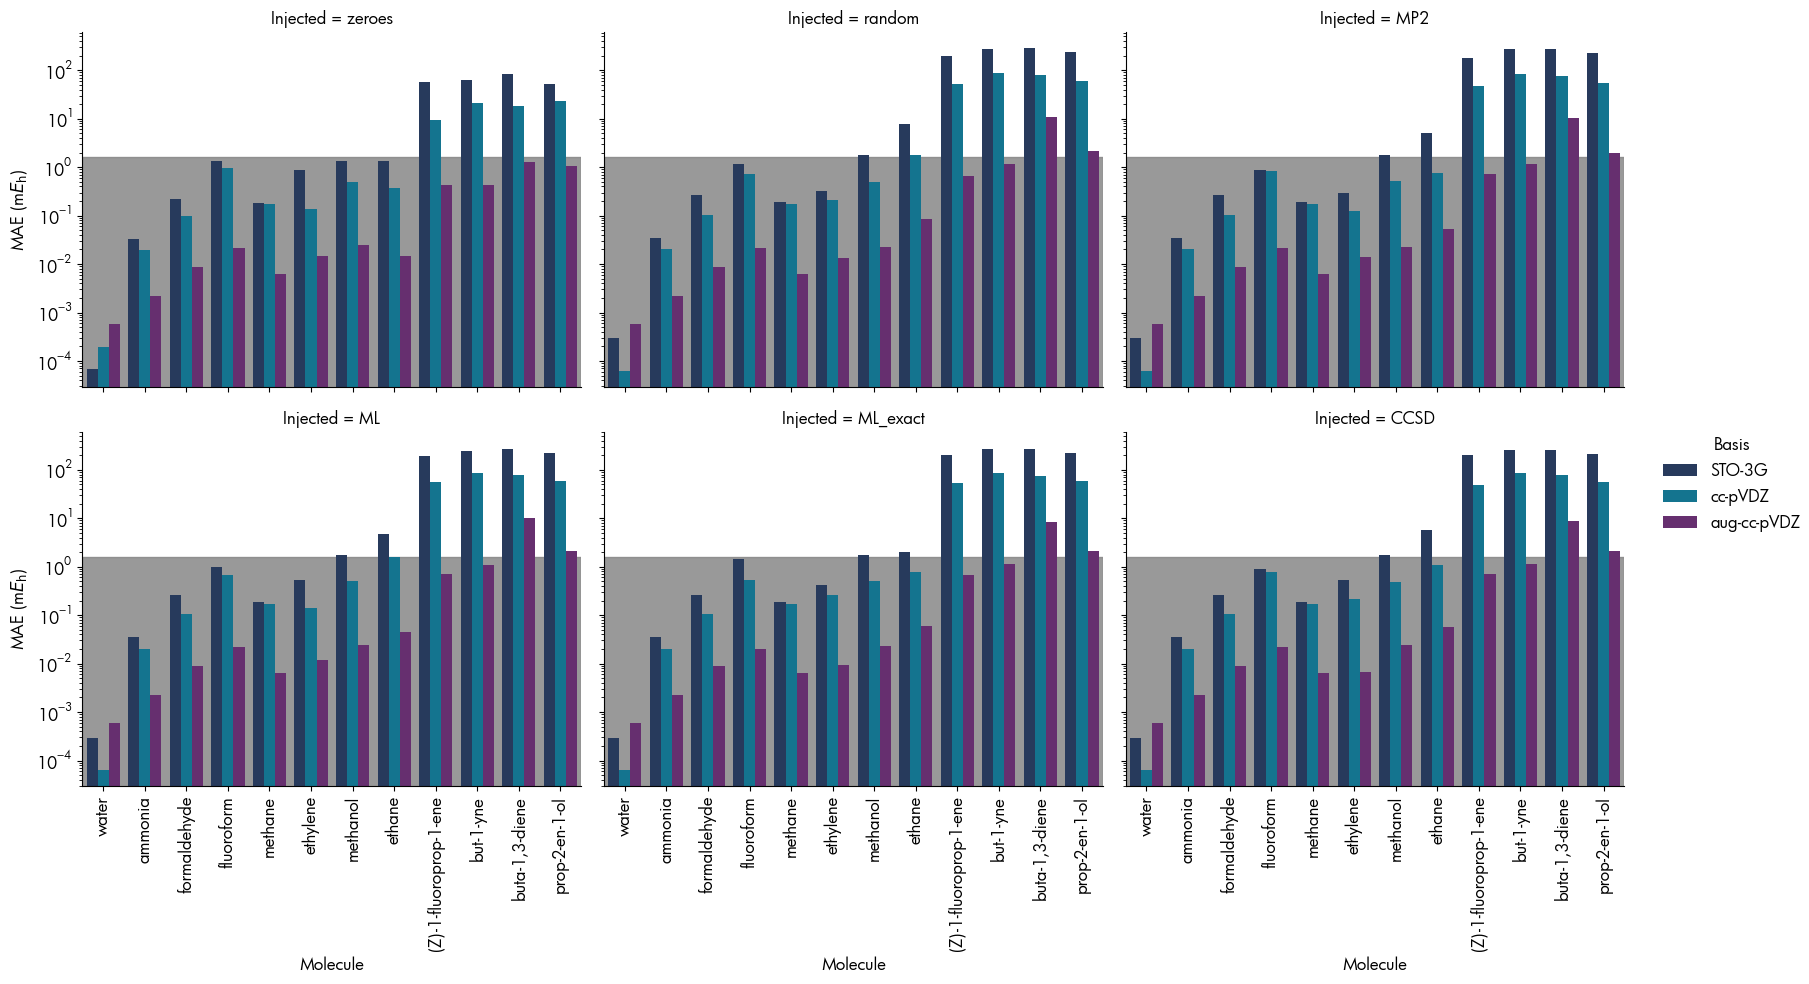

In [36]:
g = sns.catplot(data=inj_mae_df,x='Molecule',y='MAE',hue='Basis',col='Injected',kind='bar',col_order=['zeroes','random','MP2','ML','ML_exact','CCSD'],palette=palette,col_wrap=3)
for ax in g.axes.flat:
    ax.set_yscale("log")
    # ax.set_ylim(ymin - pad, ymax + pad)
    ax.axhline(0, color="gray", lw=1, ls="--", alpha=0.8)
    ax.set_ylabel(r"MAE (m$E_{\mathrm{h}}$)")
    # # Gray fill region across same y-span
    # ax.fill_between(
    #     np.linspace(-0.5, len(LUCJDF["Method"].unique()) - 0.5, 100),
    #     -1.6, 1.6,
    #     color="gray", alpha=0.2
    # )
    ax.axhspan(-1.6, 1.6, color='gray', alpha=0.8, zorder=0)
    # ax.set_xlim(-0.5, len(LUCJDF["Method"].unique()) - 0.5)

    # Rotate and align x tick labels
    for label in ax.get_xticklabels():
        # print(label)
        label.set_rotation(90)
        label.set_horizontalalignment("center")
        label.set_verticalalignment("top")
g._legend.set_bbox_to_anchor((1.1, 0.5))
g._legend.set_frame_on(False)        
# plt.legend(loc='center right', bbox_to_anchor=(1.5, 0.5))        
plt.tight_layout()        
plt.savefig("GMJ_figures/MAE_inj_mol_basis.png",dpi=300,bbox_inches='tight')

/var/folders/px/qyhp9b8j4bb0z5wgydzgkpxw0000gn/T/ipykernel_13393/2938803511.py:2: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.barplot(data=mol_mae_df,x='Molecule',y='MAE',hue='Basis',hue_order=['STO-3G','cc-pVDZ','aug-cc-pVDZ'],palette=palette)


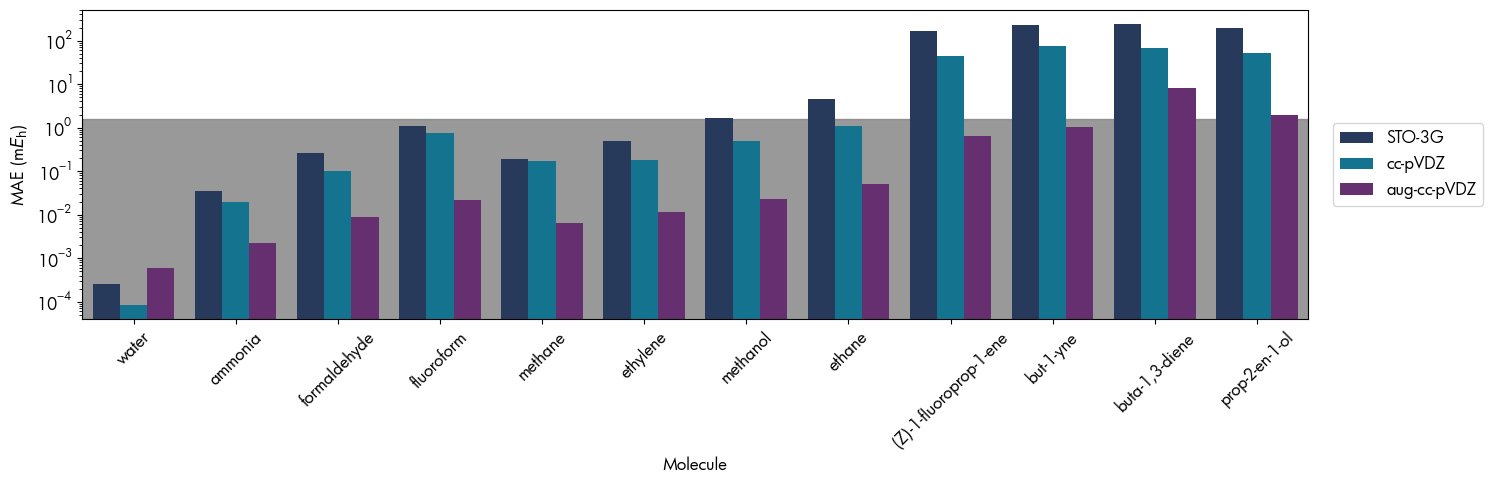

In [37]:
plt.figure(figsize=(15,5))
sns.barplot(data=mol_mae_df,x='Molecule',y='MAE',hue='Basis',hue_order=['STO-3G','cc-pVDZ','aug-cc-pVDZ'],palette=palette)
plt.yscale("log")
plt.ylabel(r"MAE (m$E_{\mathrm{h}}$)")
plt.axhspan(-1.6, 1.6, color='gray', alpha=0.8, zorder=0)
plt.xticks(rotation=45)
plt.legend(loc='center right', bbox_to_anchor=(1.15, 0.5))
plt.tight_layout()
plt.savefig("GMJ_figures/MAE_mol_basis.png",dpi=300,bbox_inches='tight')

In [38]:
for basis, inj in product(uniqueBasis,uniqueInj):
    mask = (LUCJDF['Basis Set']==basis)&(LUCJDF['Injected']==inj)
    print(f"{basis} {inj} {mean_absolute_error(LUCJDF.loc[mask,'Energy'],LUCJDF.loc[mask,'Energy (HCI)'])*1e3:.2f} mEh")

STO-3G zeroes 21.87 mEh
STO-3G random 83.81 mEh
STO-3G MP2 79.53 mEh
STO-3G ML 79.16 mEh
STO-3G ML_exact 81.18 mEh
STO-3G CCSD 79.01 mEh
cc-pVDZ zeroes 6.13 mEh
cc-pVDZ random 23.69 mEh
cc-pVDZ MP2 21.84 mEh
cc-pVDZ ML 23.46 mEh
cc-pVDZ ML_exact 22.83 mEh
cc-pVDZ CCSD 22.68 mEh
aug-cc-pVDZ zeroes 0.27 mEh
aug-cc-pVDZ random 1.24 mEh
aug-cc-pVDZ MP2 1.21 mEh
aug-cc-pVDZ ML 1.19 mEh
aug-cc-pVDZ ML_exact 1.05 mEh
aug-cc-pVDZ CCSD 1.09 mEh


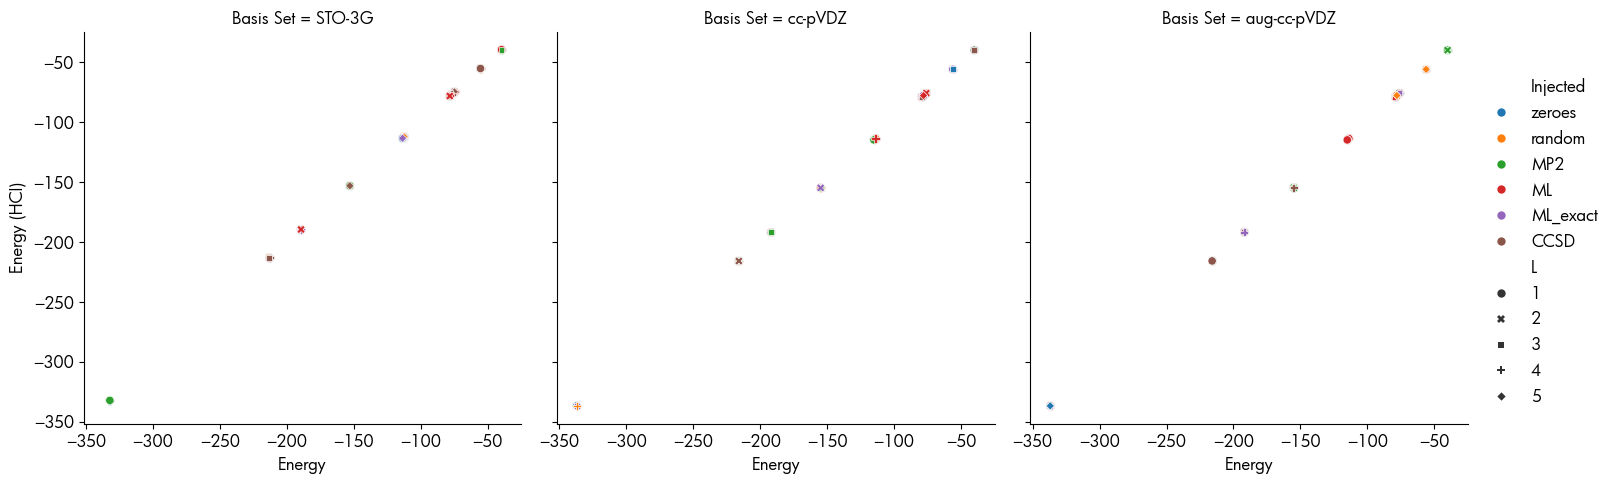

In [39]:
sns.relplot(LUCJDF, col='Basis Set', style='L', hue='Injected', x='Energy', y='Energy (HCI)', kind='scatter',col_order=uniqueBasis,hue_order=uniqueInj)

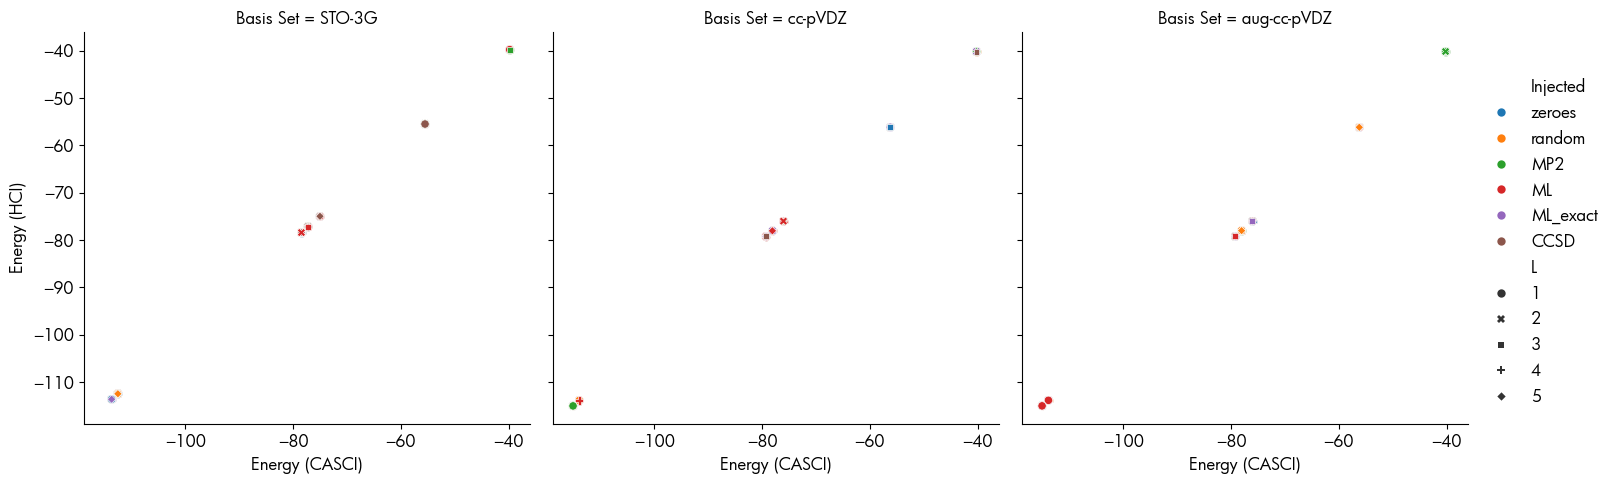

In [40]:
sns.relplot(LUCJDF, col='Basis Set', style='L', hue='Injected', x='Energy (CASCI)', y='Energy (HCI)', kind='scatter',col_order=uniqueBasis,hue_order=uniqueInj)

In [41]:
for basis in uniqueBasis:
    basismask = (LUCJDF['Basis Set'] == basis)
    # print(basis, f"{1e3*mean_absolute_error(LUCJDF.loc[basismask,'Energy'],LUCJDF.loc[basismask,'Energy (HCI)']):.2f} mEh")
    for inj in uniqueInj:
        injmask = basismask&(LUCJDF['Injected'] == inj)
        print(basis, inj, f"{1e3*mean_absolute_error(LUCJDF.loc[injmask,'Energy'],LUCJDF.loc[injmask,'Energy (HCI)']):.2f} mEh")
        # for layers in sorted(uniqueLayers):
        #     mask = injmask&(LUCJDF['L'] == layers)
        #     print(basis, inj, layers, f"{1e3*mean_absolute_error(LUCJDF.loc[mask,'Energy'],LUCJDF.loc[mask,'Energy (HCI)']):.2f} mEh")

STO-3G zeroes 21.87 mEh
STO-3G random 83.81 mEh
STO-3G MP2 79.53 mEh
STO-3G ML 79.16 mEh
STO-3G ML_exact 81.18 mEh
STO-3G CCSD 79.01 mEh
cc-pVDZ zeroes 6.13 mEh
cc-pVDZ random 23.69 mEh
cc-pVDZ MP2 21.84 mEh
cc-pVDZ ML 23.46 mEh
cc-pVDZ ML_exact 22.83 mEh
cc-pVDZ CCSD 22.68 mEh
aug-cc-pVDZ zeroes 0.27 mEh
aug-cc-pVDZ random 1.24 mEh
aug-cc-pVDZ MP2 1.21 mEh
aug-cc-pVDZ ML 1.19 mEh
aug-cc-pVDZ ML_exact 1.05 mEh
aug-cc-pVDZ CCSD 1.09 mEh


In [42]:
for basis in uniqueBasis:
    basismask = (LUCJDF['Basis Set'] == basis)&(~LUCJDF['Energy (CASCI)'].isna())
    # print(basis, f"{1e3*mean_absolute_error(LUCJDF.loc[basismask,'Energy'],LUCJDF.loc[basismask,'Energy (CASCI)']):.2f} mEh")
    # print(LUCJDF.loc[basismask,'Molecule'].unique())
    for inj in uniqueInj:
        injmask = basismask&(LUCJDF['Injected'] == inj)
        print(basis, inj, f"{1e3*mean_absolute_error(LUCJDF.loc[injmask,'Energy'],LUCJDF.loc[injmask,'Energy (CASCI)']):.2e} mEh")
        # for layers in sorted(uniqueLayers):
        #     mask = injmask&(LUCJDF['L'] == layers)
        #     print(basis, inj, layers, f"{1e3*mean_absolute_error(LUCJDF.loc[mask,'Energy'],LUCJDF.loc[mask,'Energy (CASCI)']):.2f} mEh")

STO-3G zeroes 8.47e-01 mEh
STO-3G random 1.91e+00 mEh
STO-3G MP2 1.41e+00 mEh
STO-3G ML 1.33e+00 mEh
STO-3G ML_exact 9.46e-01 mEh
STO-3G CCSD 1.51e+00 mEh
cc-pVDZ zeroes 8.60e-02 mEh
cc-pVDZ random 4.23e-01 mEh
cc-pVDZ MP2 2.59e-01 mEh
cc-pVDZ ML 3.66e-01 mEh
cc-pVDZ ML_exact 2.57e-01 mEh
cc-pVDZ CCSD 2.85e-01 mEh
aug-cc-pVDZ zeroes 2.17e-03 mEh
aug-cc-pVDZ random 1.70e-02 mEh
aug-cc-pVDZ MP2 1.34e-02 mEh
aug-cc-pVDZ ML 1.08e-02 mEh
aug-cc-pVDZ ML_exact 1.38e-02 mEh
aug-cc-pVDZ CCSD 1.39e-02 mEh


In [43]:
LUCJDF[LUCJDF['Energy (CASCI)'].isna()]['Molecule'].unique()

array(['but-1-yne', '(Z)-1-fluoroprop-1-ene', 'fluoroform',
       'buta-1,3-diene', 'prop-2-en-1-ol'], dtype=object)

In [44]:
ampdf = pd.read_excel("amplitude_data.xlsx",index_col=0).rename(columns={'molecule':'Molecule','basis':'Basis Set','Amplitude':'Injected'})
ampdf['Injected'] = [i.replace("t2_rand","random") if i=='t2_rand' else i.replace("t2_","") for i in ampdf['Injected']]
uniAmpCol = [i for i in ampdf.columns if i not in LUCJDF.columns]
# uniLUCCol = [i for i in LUCJDF.columns if i not in ampdf.columns]

stackedamp = []
for basis, inj, layer, mol in product(uniqueBasis, uniqueInj, uniqueLayers, uniqueMol):
    ampmask = (ampdf['Molecule']==mol) & (ampdf['Basis Set']==basis) & (ampdf['Injected']==inj)
    lucjdfmask = (LUCJDF['Molecule']==mol) & (LUCJDF['Basis Set']==basis) & (LUCJDF['Injected']==inj) & (LUCJDF['L']==layer)

    tmplucj = LUCJDF.loc[lucjdfmask, :].reset_index(drop=True)
    tmpamp = ampdf.loc[ampmask, uniAmpCol].reset_index(drop=True)
    
    combined = pd.concat([tmplucj, tmpamp], axis=1)
    
    stackedamp.append(combined)
stackedamp = pd.concat(stackedamp).reset_index(drop=True)
stackedamp.fillna(0,inplace=True)

In [45]:
stackedamp

,Basis Set,Molecule,Method,L,Injected,Energy,n_atoms,Deviation,Energy (HCI),Energy (HF),Energy (CASCI),MAE,MSE,MAPE,amplitude_generation_times
0,STO-3G,water,LUCJ(L=1),1,zeroes,-75.009478,3,0.000028,-75.009478,-74.960552,-75.009479,0.006494,0.000257,0.680440,0.000069
1,STO-3G,ammonia,LUCJ(L=1),1,zeroes,-55.519928,4,-0.033595,-55.519894,-55.454318,-55.519929,0.006071,0.000151,1.001152,0.000031
2,STO-3G,formaldehyde,LUCJ(L=1),1,zeroes,-112.501188,4,-0.200766,-112.500988,-112.353755,-112.501250,0.002182,0.000089,0.995581,0.000096
3,STO-3G,fluoroform,LUCJ(L=1),1,zeroes,-332.223188,5,-1.493010,-332.221695,-332.097592,0.000000,0.001350,0.000012,1.013329,0.000048
4,STO-3G,methane,LUCJ(L=1),1,zeroes,-39.806152,5,-0.183666,-39.805968,-39.726623,-39.806157,0.005258,0.000109,1.000062,0.000041
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1075,aug-cc-pVDZ,ethane,LUCJ(L=5),5,CCSD,-79.237052,8,0.076892,-79.237128,-79.236978,-79.237150,0.000000,0.000000,0.000000,0.000000
1076,aug-cc-pVDZ,(Z)-1-fluoroprop-1-ene,LUCJ(L=5),5,CCSD,-215.949697,9,0.714602,-215.950412,-215.949690,0.000000,0.000000,0.000000,0.000000,0.000000
1077,aug-cc-pVDZ,but-1-yne,LUCJ(L=5),5,CCSD,-154.916857,10,1.085456,-154.917942,-154.916785,0.000000,0.000000,0.000000,0.000000,0.000000
1078,aug-cc-pVDZ,"buta-1,3-diene",LUCJ(L=5),5,CCSD,-154.939926,10,10.702409,-154.950628,-154.939913,0.000000,0.000000,0.000000,0.000000,0.000000


In [46]:
stackedamp

,Basis Set,Molecule,Method,L,Injected,Energy,n_atoms,Deviation,Energy (HCI),Energy (HF),Energy (CASCI),MAE,MSE,MAPE,amplitude_generation_times
0,STO-3G,water,LUCJ(L=1),1,zeroes,-75.009478,3,0.000028,-75.009478,-74.960552,-75.009479,0.006494,0.000257,0.680440,0.000069
1,STO-3G,ammonia,LUCJ(L=1),1,zeroes,-55.519928,4,-0.033595,-55.519894,-55.454318,-55.519929,0.006071,0.000151,1.001152,0.000031
2,STO-3G,formaldehyde,LUCJ(L=1),1,zeroes,-112.501188,4,-0.200766,-112.500988,-112.353755,-112.501250,0.002182,0.000089,0.995581,0.000096
3,STO-3G,fluoroform,LUCJ(L=1),1,zeroes,-332.223188,5,-1.493010,-332.221695,-332.097592,0.000000,0.001350,0.000012,1.013329,0.000048
4,STO-3G,methane,LUCJ(L=1),1,zeroes,-39.806152,5,-0.183666,-39.805968,-39.726623,-39.806157,0.005258,0.000109,1.000062,0.000041
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1075,aug-cc-pVDZ,ethane,LUCJ(L=5),5,CCSD,-79.237052,8,0.076892,-79.237128,-79.236978,-79.237150,0.000000,0.000000,0.000000,0.000000
1076,aug-cc-pVDZ,(Z)-1-fluoroprop-1-ene,LUCJ(L=5),5,CCSD,-215.949697,9,0.714602,-215.950412,-215.949690,0.000000,0.000000,0.000000,0.000000,0.000000
1077,aug-cc-pVDZ,but-1-yne,LUCJ(L=5),5,CCSD,-154.916857,10,1.085456,-154.917942,-154.916785,0.000000,0.000000,0.000000,0.000000,0.000000
1078,aug-cc-pVDZ,"buta-1,3-diene",LUCJ(L=5),5,CCSD,-154.939926,10,10.702409,-154.950628,-154.939913,0.000000,0.000000,0.000000,0.000000,0.000000


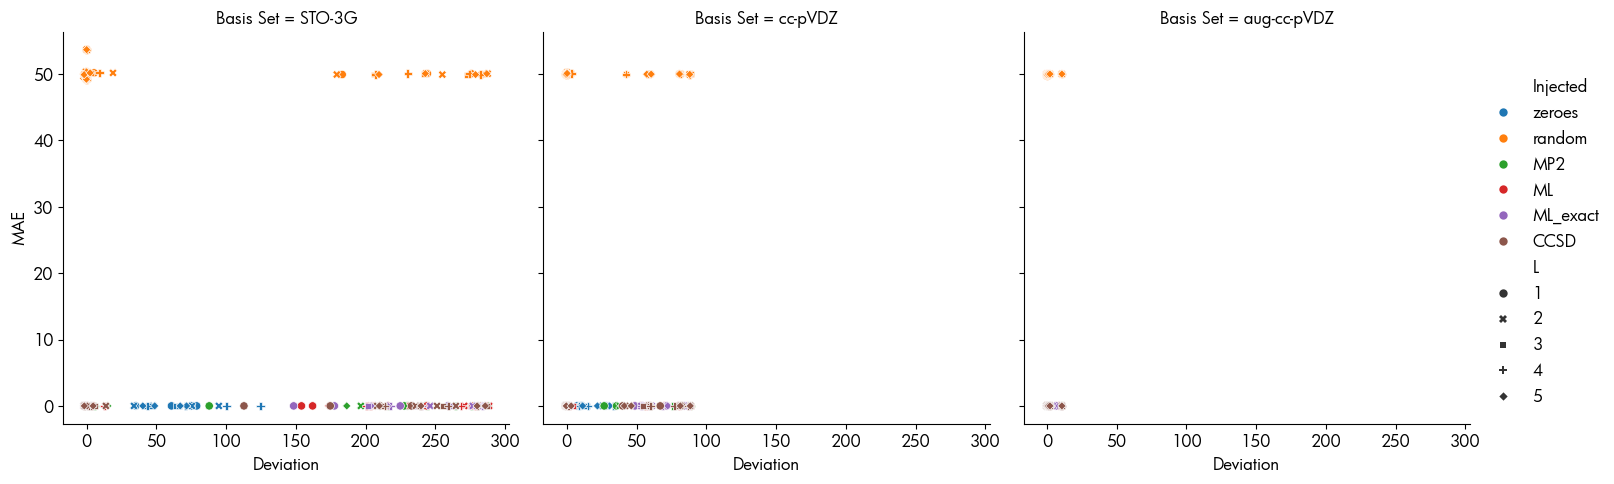

In [47]:
sns.relplot(stackedamp, col='Basis Set', style='L', hue='Injected', x='Deviation', y='MAE', kind='scatter',col_order=uniqueBasis,hue_order=uniqueInj)

In [48]:
stackedamp[stackedamp['Injected']=='CCSD']

,Basis Set,Molecule,Method,L,Injected,Energy,n_atoms,Deviation,Energy (HCI),Energy (HF),Energy (CASCI),MAE,MSE,MAPE,amplitude_generation_times
300,STO-3G,water,LUCJ(L=1),1,CCSD,-75.009479,3,-0.000292,-75.009478,-74.960552,-75.009479,0.0,0.0,0.0,0.0
301,STO-3G,ammonia,LUCJ(L=1),1,CCSD,-55.519929,4,-0.034925,-55.519894,-55.454318,-55.519929,0.0,0.0,0.0,0.0
302,STO-3G,formaldehyde,LUCJ(L=1),1,CCSD,-112.501250,4,-0.262286,-112.500988,-112.353755,-112.501250,0.0,0.0,0.0,0.0
303,STO-3G,fluoroform,LUCJ(L=1),1,CCSD,-332.223435,5,-1.739610,-332.221695,-332.097592,0.000000,0.0,0.0,0.0,0.0
304,STO-3G,methane,LUCJ(L=1),1,CCSD,-39.806157,5,-0.188306,-39.805968,-39.726623,-39.806157,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1075,aug-cc-pVDZ,ethane,LUCJ(L=5),5,CCSD,-79.237052,8,0.076892,-79.237128,-79.236978,-79.237150,0.0,0.0,0.0,0.0
1076,aug-cc-pVDZ,(Z)-1-fluoroprop-1-ene,LUCJ(L=5),5,CCSD,-215.949697,9,0.714602,-215.950412,-215.949690,0.000000,0.0,0.0,0.0,0.0
1077,aug-cc-pVDZ,but-1-yne,LUCJ(L=5),5,CCSD,-154.916857,10,1.085456,-154.917942,-154.916785,0.000000,0.0,0.0,0.0,0.0
1078,aug-cc-pVDZ,"buta-1,3-diene",LUCJ(L=5),5,CCSD,-154.939926,10,10.702409,-154.950628,-154.939913,0.000000,0.0,0.0,0.0,0.0


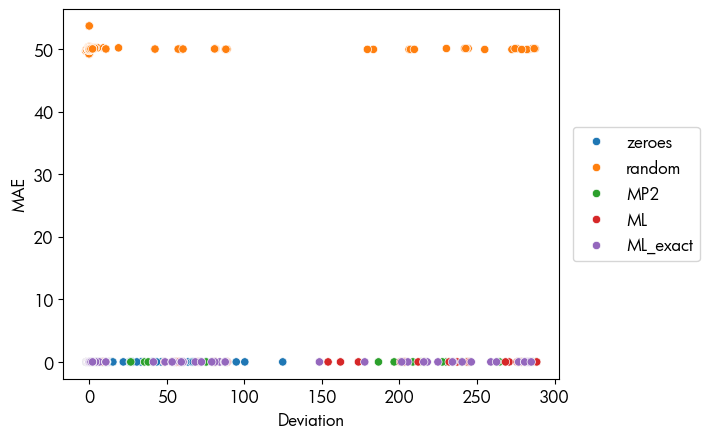

In [49]:
sns.scatterplot(data=stackedamp[stackedamp['Injected']!='CCSD'],x='Deviation',y='MAE',hue='Injected')
# plt.xticks(rotation=45)
plt.legend(loc='center right', bbox_to_anchor=(1.3, 0.5))

In [50]:
len(uniqueBasis)*len(uniqueMol)*len(uniqueInj)

216

In [51]:
# Save bad ones

bad_df = LUCJDF[((LUCJDF['Energy (HCI)'] - LUCJDF['Energy']).abs()*1e3)>=1.6]


# bad_df.sort_values(by=['Molecule','Basis Set','L',"Injected"]).reset_index(drop=True).to_excel("repostprocess.xlsx")
LUCJDF.sort_values(by=['Molecule','Basis Set','L',"Injected"]).reset_index(drop=True).to_excel("repostprocess.xlsx")

In [52]:
bad_df

,Basis Set,Molecule,Method,L,Injected,Energy,n_atoms,Deviation,Energy (HCI),Energy (HF),Energy (CASCI)
5,cc-pVDZ,ethane,LUCJ(L=3),3,ML_exact,-79.257913,8,2.018052,-79.259931,-79.234612,-79.260721
8,STO-3G,but-1-yne,LUCJ(L=5),5,random,-153.029261,10,278.840692,-153.308102,-153.024895,NaN
9,STO-3G,but-1-yne,LUCJ(L=5),5,zeroes,-153.259322,10,48.779682,-153.308102,-153.024895,NaN
14,STO-3G,(Z)-1-fluoroprop-1-ene,LUCJ(L=3),3,MP2,-213.140900,9,202.713590,-213.343614,-213.116469,NaN
27,STO-3G,"buta-1,3-diene",LUCJ(L=3),3,random,-153.019680,10,285.729082,-153.305409,-153.016542,NaN
...,...,...,...,...,...,...,...,...,...,...,...
1060,STO-3G,methanol,LUCJ(L=1),1,random,-113.662550,6,-1.784555,-113.660765,-113.544759,-113.662609
1062,STO-3G,ethane,LUCJ(L=2),2,ML,-78.446349,8,2.605768,-78.448955,-78.305816,-78.453232
1072,aug-cc-pVDZ,"buta-1,3-diene",LUCJ(L=4),4,CCSD,-154.939961,10,10.667699,-154.950628,-154.939913,NaN
1074,STO-3G,fluoroform,LUCJ(L=1),1,MP2,-332.223351,5,-1.655590,-332.221695,-332.097592,NaN


In [53]:
bad_df.shape

(352, 11)

<Axes: xlabel='Injected', ylabel='Deviation'>

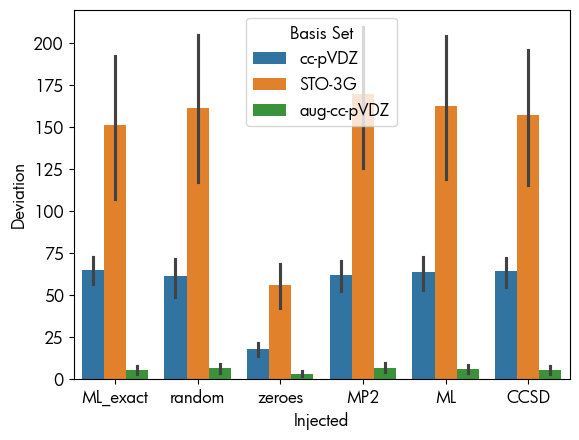

In [54]:
sns.barplot(LUCJDF[LUCJDF['Deviation'].abs()>=1.6],y='Deviation',x='Injected',hue='Basis Set')

<Axes: xlabel='Deviation', ylabel='Density'>

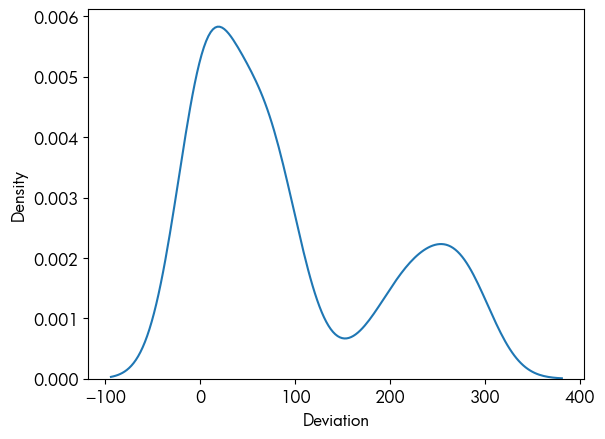

In [55]:
sns.kdeplot(data=bad_df,x='Deviation')

In [56]:
with open("rerun_trash.sh",'w') as f:
    for _, row in LUCJDF.loc[LUCJDF['Energy']<-1e4,['Basis Set','Molecule','L','Injected']].iterrows():
        basis, name, layer, injection = row.to_list()
        filename = f"{name}_LUCJ_L{layer}_{basis}_{injection}.sh"
        if os.path.exists(os.path.join('postprocess',filename)) is False:
            print(filename)
        else:
            f.write(filename+"\n")

In [57]:
[n_atoms_dict[i] for i in bad_df['Molecule'].drop_duplicates().values]

[8, 10, 9, 10, 10, 5, 6, 6]

In [58]:
n_atoms_dict

{'water': 3,
 'methane': 5,
 'ammonia': 4,
 'ethane': 8,
 'methanol': 6,
 'ethylene': 6,
 'formaldehyde': 4,
 'prop-2-en-1-ol': 10,
 'but-1-yne': 10,
 'fluoroform': 5,
 'buta-1,3-diene': 10,
 '(Z)-1-fluoroprop-1-ene': 9}

/var/folders/px/qyhp9b8j4bb0z5wgydzgkpxw0000gn/T/ipykernel_13393/2982542141.py:1: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  g = sns.catplot(data=LUCJDF,hue='L',y='Deviation',row='Injected',col='Basis Set',kind='bar',x='Molecule',col_order=['STO-3G','cc-pVDZ','aug-cc-pVDZ'],row_order=uniqueInj,palette=palette)


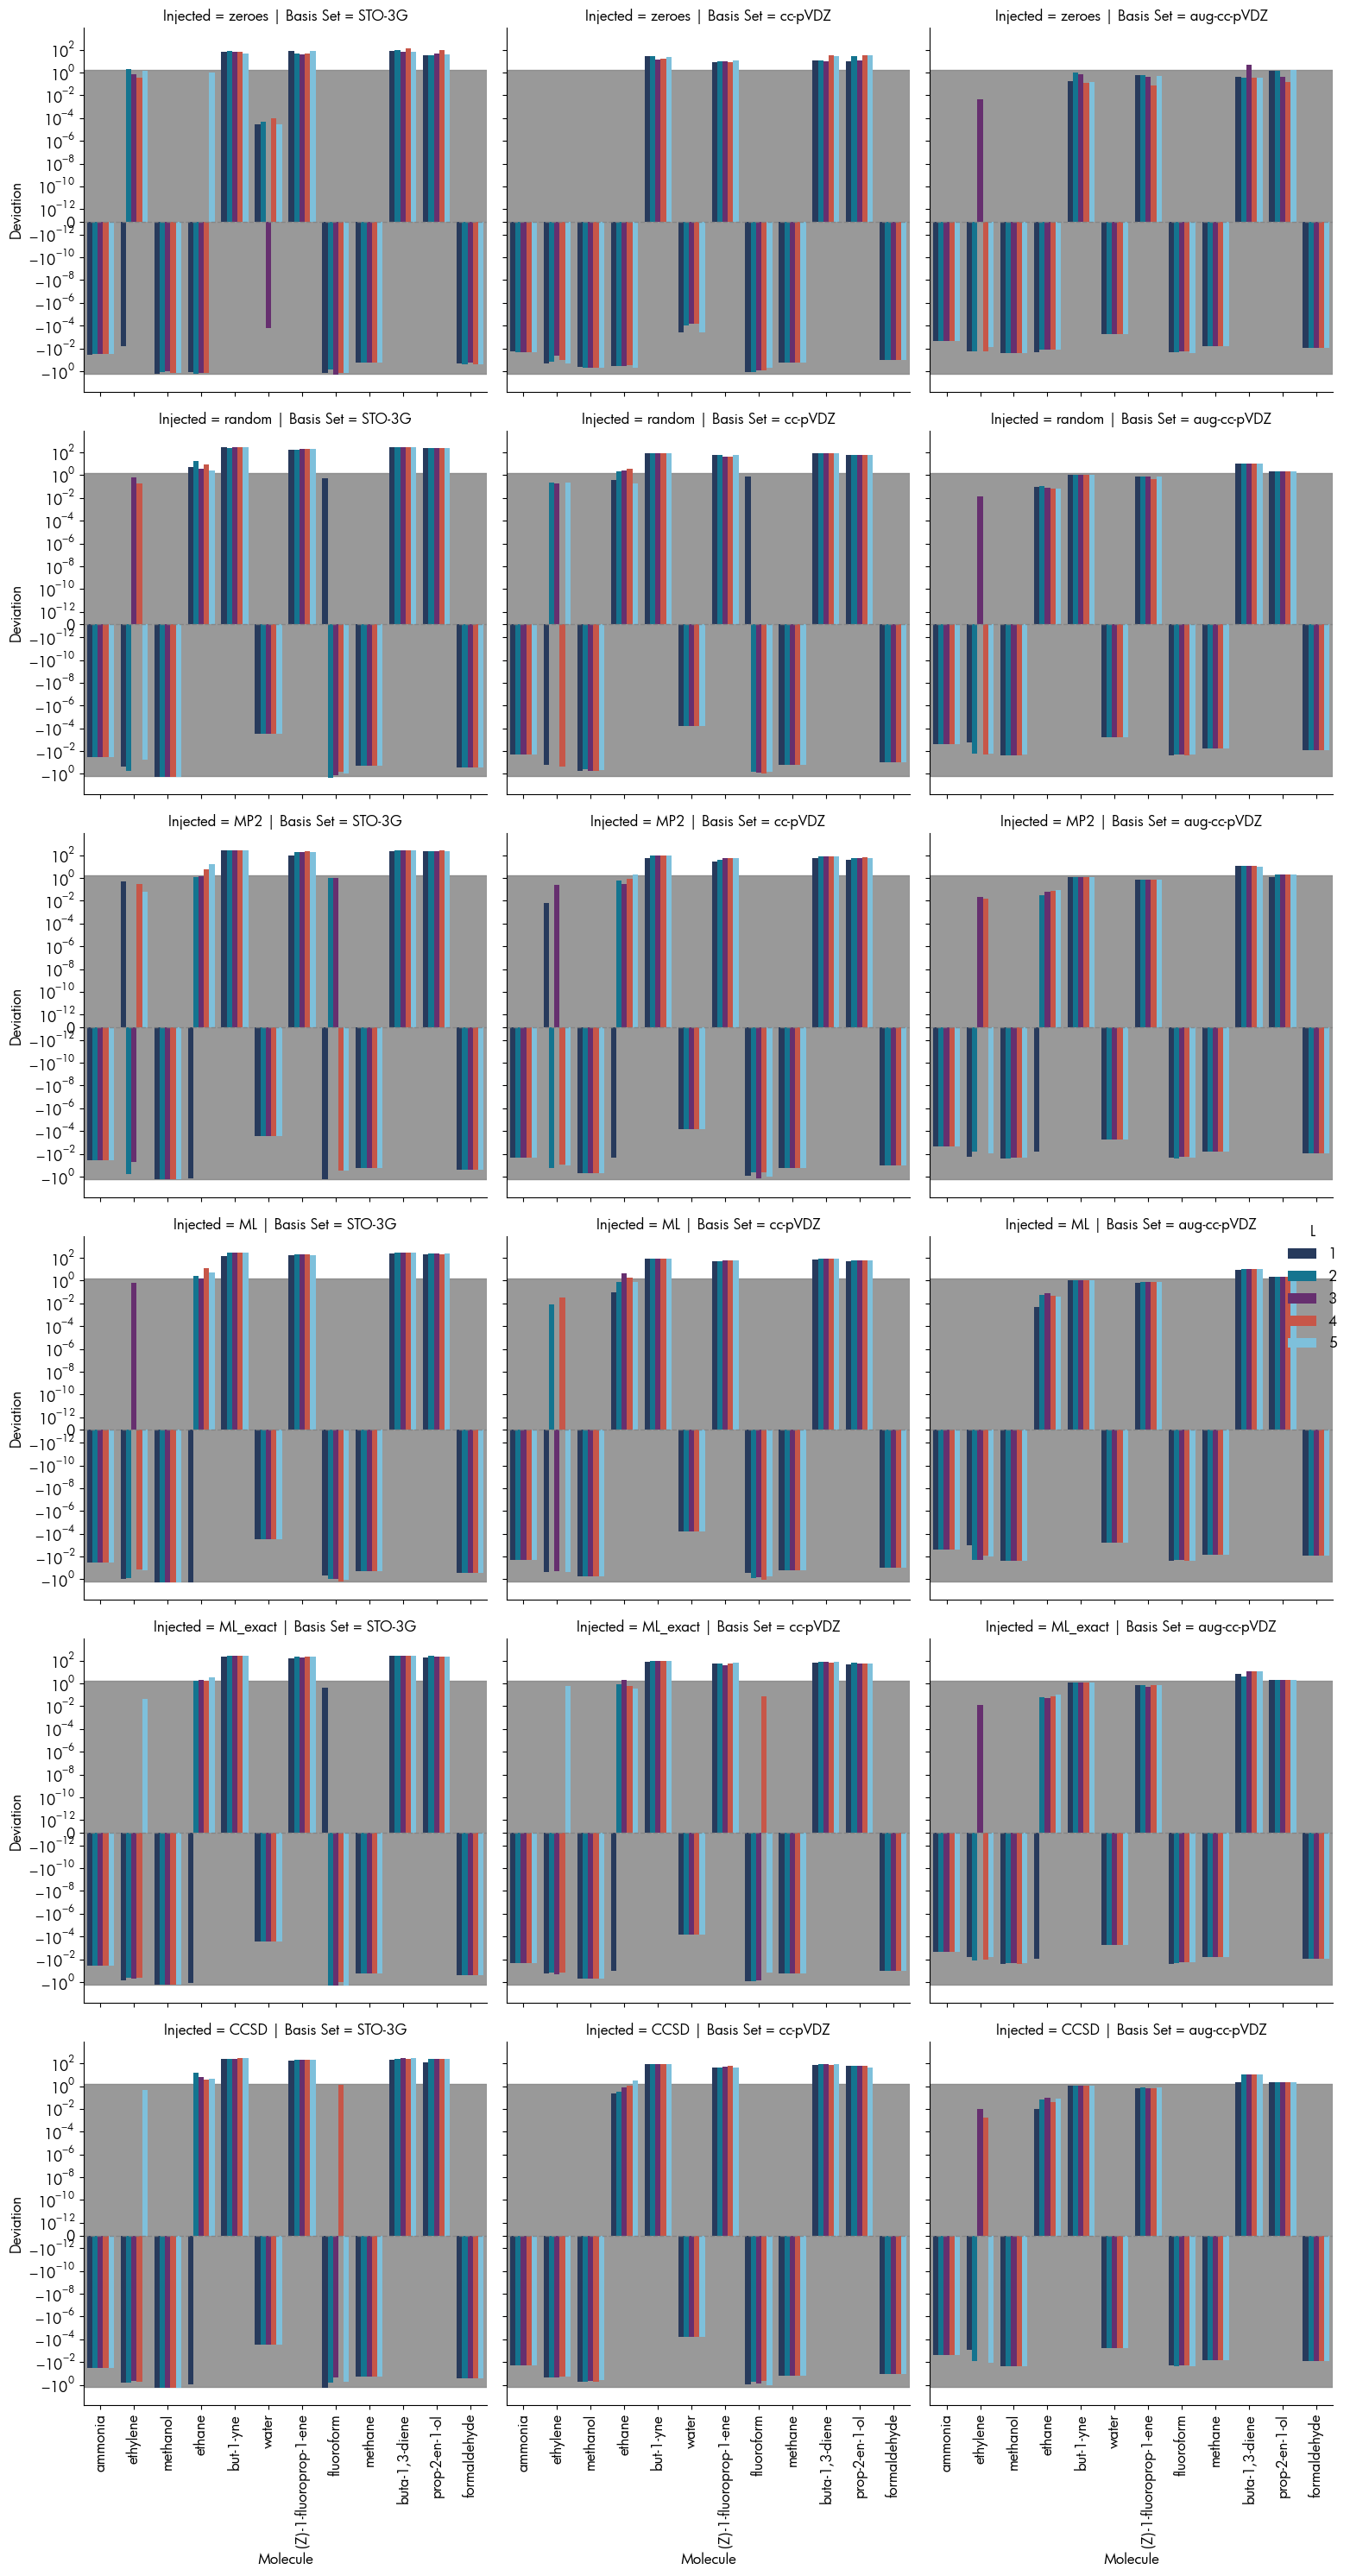

In [59]:
g = sns.catplot(data=LUCJDF,hue='L',y='Deviation',row='Injected',col='Basis Set',kind='bar',x='Molecule',col_order=['STO-3G','cc-pVDZ','aug-cc-pVDZ'],row_order=uniqueInj,palette=palette)
# Apply styling to **all subplots**
for ax in g.axes.flat:
    ax.set_yscale("symlog", linthresh=1e-12)
    # ax.set_ylim(ymin - pad, ymax + pad)
    ax.axhline(0, color="gray", lw=1, ls="--", alpha=0.8)
    
    # # Gray fill region across same y-span
    # ax.fill_between(
    #     np.linspace(-0.5, len(LUCJDF["Method"].unique()) - 0.5, 100),
    #     -1.6, 1.6,
    #     color="gray", alpha=0.2
    # )
    ax.axhspan(-1.6, 1.6, color='gray', alpha=0.8, zorder=0)
    # ax.set_xlim(-0.5, len(LUCJDF["Method"].unique()) - 0.5)

    # Rotate and align x tick labels
    for label in ax.get_xticklabels():
        # print(label)
        label.set_rotation(90)
        label.set_horizontalalignment("center")
        label.set_verticalalignment("top")
plt.tight_layout()        
plt.savefig("GMJ_figures/deviations.png",dpi=300,bbox_inches='tight')

In [60]:
LUCJDF['Deviation'].describe()

count    1080.000000
mean       30.316462
std        71.395092
min        -2.211000
25%        -0.103185
50%        -0.000589
75%         5.455880
max       288.541702
Name: Deviation, dtype: float64

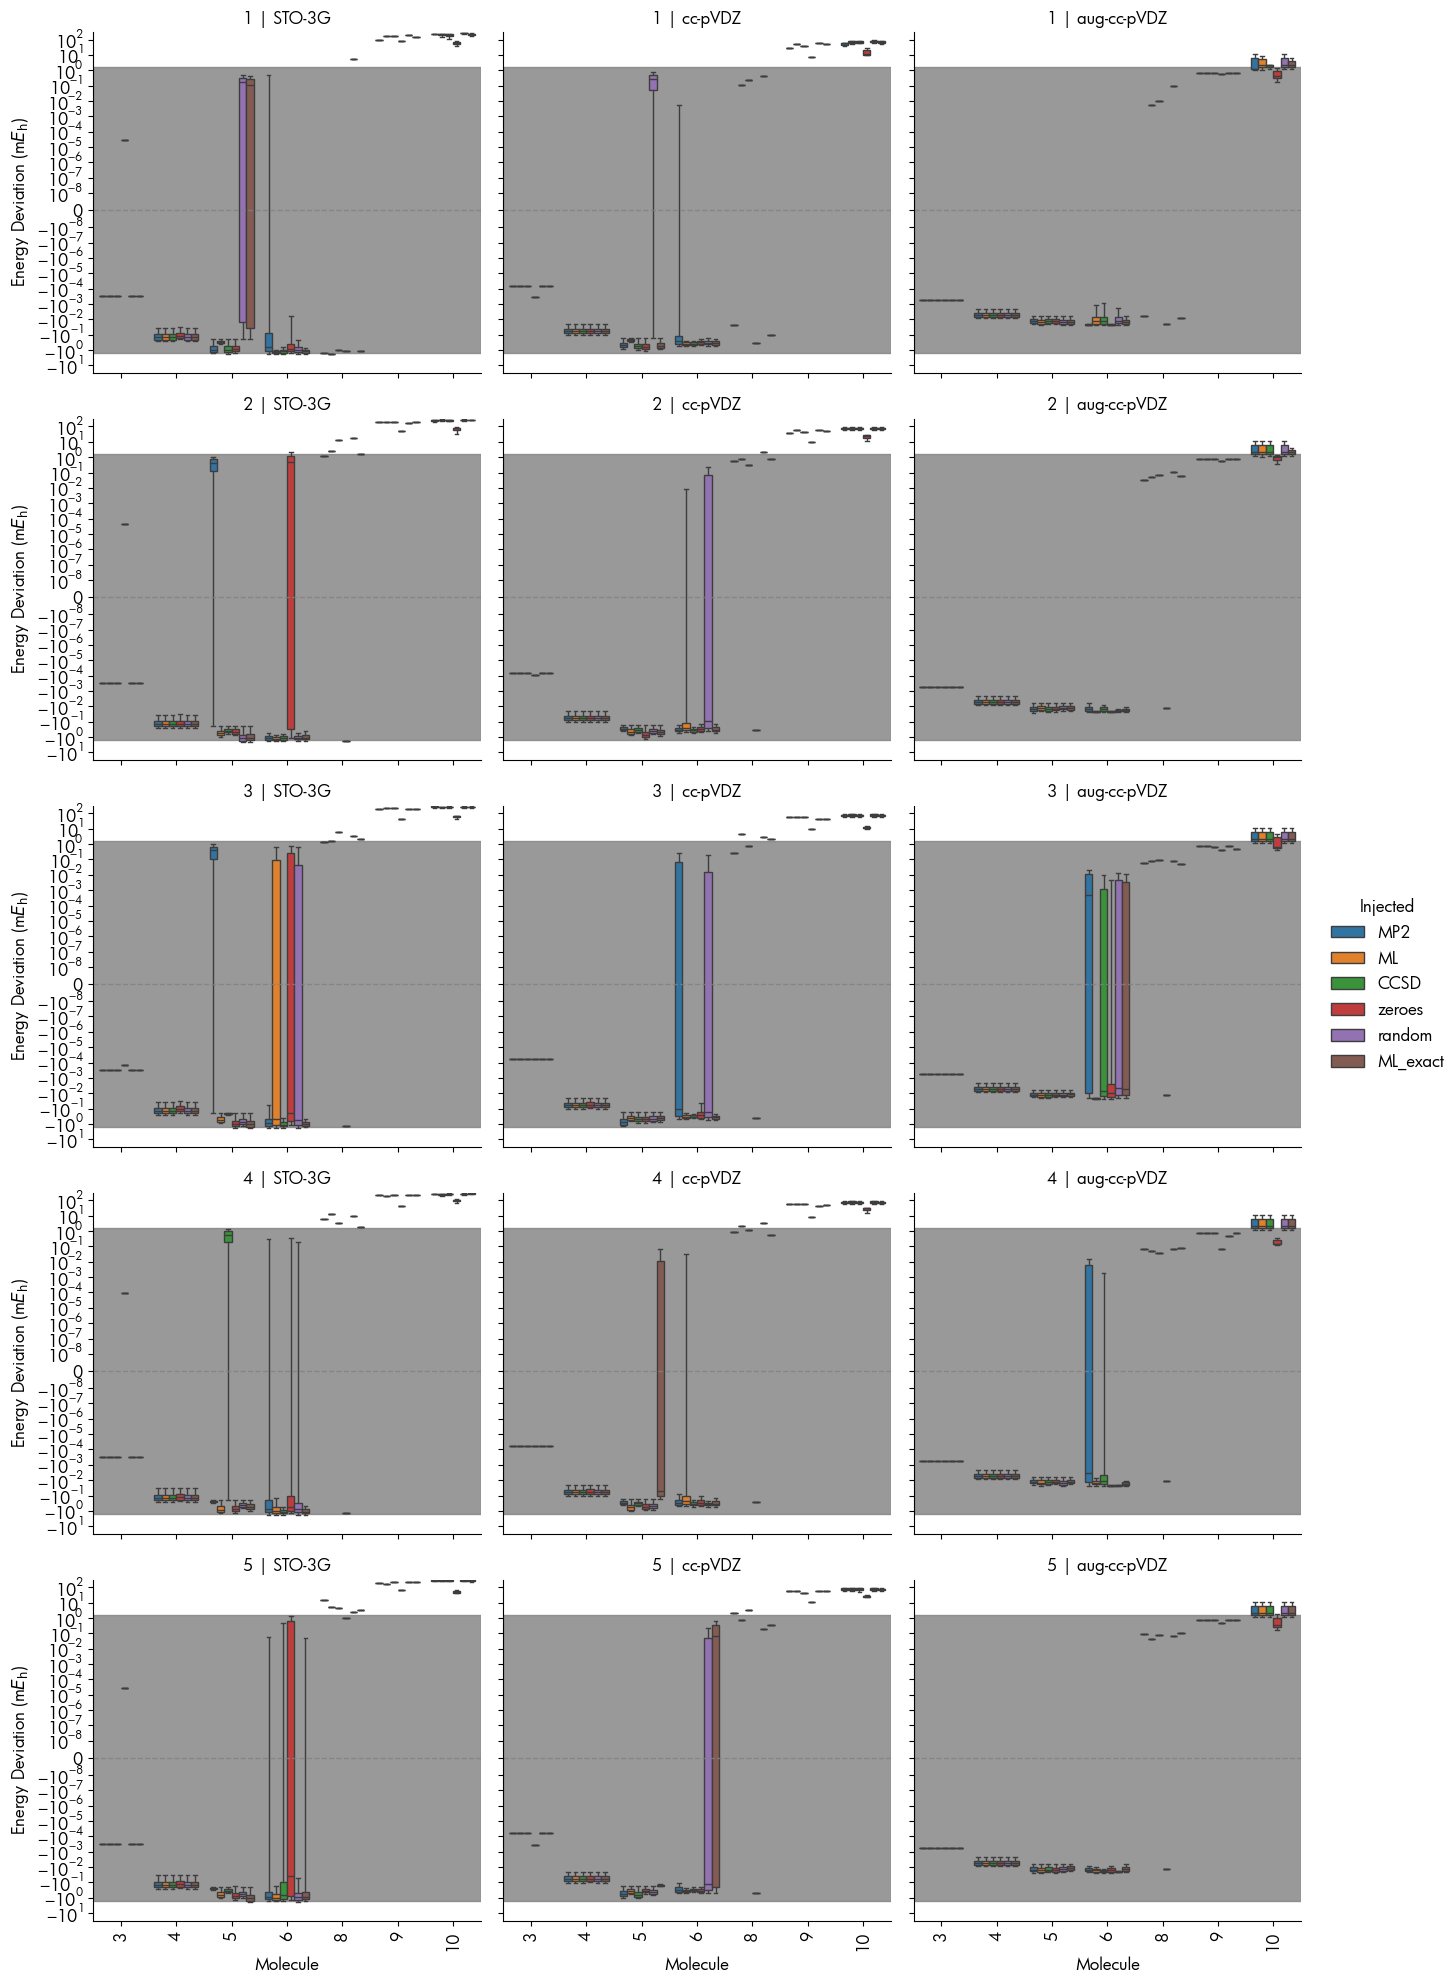

In [61]:
g = sns.catplot(LUCJDF,
                col='Basis Set',
                row='L',
                x='n_atoms',
                y='Deviation',
                hue='Injected',
                kind='box',
                height=4, 
                # aspect=0.6,
                whis=(0, 100),
                )


# Compute global deviation range for consistent shading/scaling
ymin = LUCJDF["Deviation"].min()
ymax = LUCJDF["Deviation"].max()
pad = 0.1 * max(abs(ymin), abs(ymax))

# Apply styling to **all subplots**
for ax in g.axes.flat:
    ax.set_yscale("symlog", linthresh=1e-8)
    ax.set_ylim(ymin - pad, ymax + pad)
    ax.axhline(0, color="gray", lw=1, ls="--", alpha=0.8)
    
    # # Gray fill region across same y-span
    # ax.fill_between(
    #     np.linspace(-0.5, len(LUCJDF["Method"].unique()) - 0.5, 100),
    #     -1.6, 1.6,
    #     color="gray", alpha=0.2
    # )
    ax.axhspan(-1.6, 1.6, color='gray', alpha=0.8, zorder=0)
    # ax.set_xlim(-0.5, len(LUCJDF["Method"].unique()) - 0.5)

    # Rotate and align x tick labels
    for label in ax.get_xticklabels():
        # print(label)
        label.set_rotation(90)
        label.set_horizontalalignment("center")
        label.set_verticalalignment("top")

# Adjust titles and axis labels
g.set_titles(col_template="{col_name}", row_template="{row_name}")
g.set_axis_labels("Molecule", r"Energy Deviation (m$E_{\mathrm{h}}$)")


# Move legend outside the main plot (right side)
g._legend.set_bbox_to_anchor((1.1, 0.5))
g._legend.set_frame_on(False)
plt.subplots_adjust(right=0.85)  # make space for legend

plt.tight_layout()
plt.show()

In [62]:
LUCJDF['Deviation'].max(),LUCJDF['Deviation'].min()

(np.float64(288.54170180341043), np.float64(-2.2109999333110864))

# Deviation from CCSD initialized

In [63]:
for basis, layer, mol in product(uniqueBasis,uniqueLayers,uniqueMol):
    mask = ((LUCJDF['Basis Set']==basis) &
            (LUCJDF['L']==layer) &
            (LUCJDF['Molecule']==mol) 
           
           )
    print(mol,basis)
    LUCJDF.loc[mask,'Deviation'] = (LUCJDF.loc[mask,"Energy"] - LUCJDF.loc[mask&(LUCJDF['Injected']=='CCSD'),'Energy'].values)*1e3
    # try:
    #     LUCJDF.loc[mask,'Deviation'] = (LUCJDF.loc[mask,"Energy"] - energyDF.loc[(energyDF['Molecule']==mol)&(energyDF['Basis Set']==basis)&(energyDF['Method']=='SHCI'),'Energy'].values[0])*1e3
    # except:
    #     mol = moldf.loc[moldf['molecule'] == mol,'mol_filename'].values[0].replace('.xyz','')
    #     LUCJDF.loc[mask,'Deviation'] = (LUCJDF.loc[mask,"Energy"] - energyDF.loc[(energyDF['Molecule']==mol)&(energyDF['Basis Set']==basis)&(energyDF['Method']=='SHCI'),'Energy'].values[0])*1e3

water STO-3G
ammonia STO-3G
formaldehyde STO-3G
fluoroform STO-3G
methane STO-3G
ethylene STO-3G
methanol STO-3G
ethane STO-3G
(Z)-1-fluoroprop-1-ene STO-3G
but-1-yne STO-3G
buta-1,3-diene STO-3G
prop-2-en-1-ol STO-3G
water STO-3G
ammonia STO-3G
formaldehyde STO-3G
fluoroform STO-3G
methane STO-3G
ethylene STO-3G
methanol STO-3G
ethane STO-3G
(Z)-1-fluoroprop-1-ene STO-3G
but-1-yne STO-3G
buta-1,3-diene STO-3G
prop-2-en-1-ol STO-3G
water STO-3G
ammonia STO-3G
formaldehyde STO-3G
fluoroform STO-3G
methane STO-3G
ethylene STO-3G
methanol STO-3G
ethane STO-3G
(Z)-1-fluoroprop-1-ene STO-3G
but-1-yne STO-3G
buta-1,3-diene STO-3G
prop-2-en-1-ol STO-3G
water STO-3G
ammonia STO-3G
formaldehyde STO-3G
fluoroform STO-3G
methane STO-3G
ethylene STO-3G
methanol STO-3G
ethane STO-3G
(Z)-1-fluoroprop-1-ene STO-3G
but-1-yne STO-3G
buta-1,3-diene STO-3G
prop-2-en-1-ol STO-3G
water STO-3G
ammonia STO-3G
formaldehyde STO-3G
fluoroform STO-3G
methane STO-3G
ethylene STO-3G
methanol STO-3G
ethane STO-3G
(

In [64]:
LUCJDF.loc[LUCJDF['Deviation'].idxmax()]

Basis Set                 STO-3G
Molecule          prop-2-en-1-ol
Method                 LUCJ(L=1)
L                              1
Injected                  random
Energy               -189.482689
n_atoms                       10
Deviation              131.53918
Energy (HCI)         -189.727016
Energy (HF)          -189.480427
Energy (CASCI)               NaN
Name: 269, dtype: object

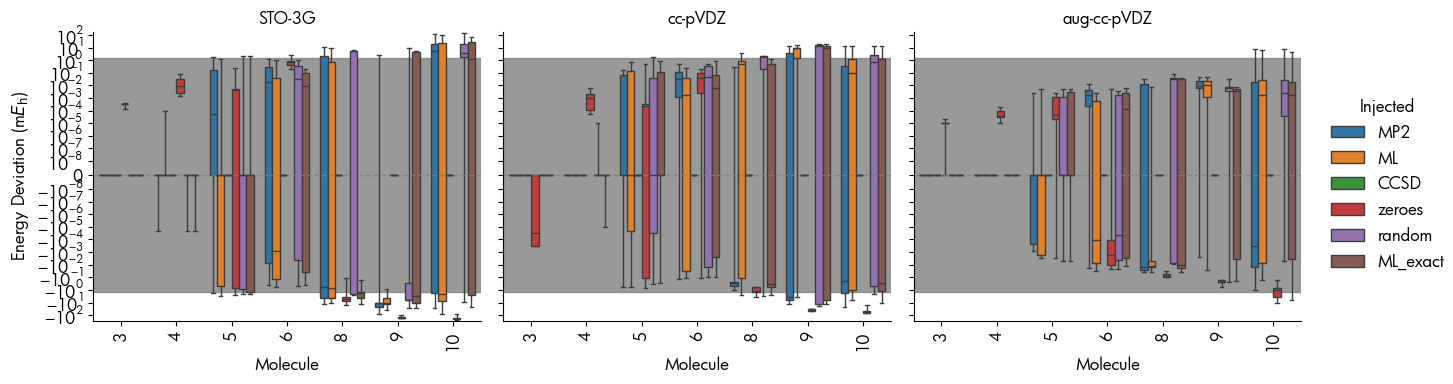

In [65]:
g = sns.catplot(LUCJDF, #[LUCJDF['Injected']!='CCSD'],
                col='Basis Set',
                # col='L',
                x='n_atoms',
                y='Deviation',
                hue='Injected',
                kind='box',
                height=4, 
                # aspect=0.6,
                whis=(0, 100),
                )


# Compute global deviation range for consistent shading/scaling
ymin = LUCJDF["Deviation"].min()
ymax = LUCJDF["Deviation"].max()
pad = 0.2 * max(abs(ymin), abs(ymax))

# Apply styling to **all subplots**
for ax in g.axes.flat:
    ax.set_yscale("symlog", linthresh=1e-8)
    ax.set_ylim(ymin - pad, ymax + pad)
    ax.axhline(0, color="gray", lw=1, ls="--", alpha=0.8)
    
    # # Gray fill region across same y-span
    # ax.fill_between(
    #     np.linspace(-0.5, len(LUCJDF["Method"].unique()) - 0.5, 100),
    #     -1.6, 1.6,
    #     color="gray", alpha=0.2
    # )
    ax.axhspan(-1.6, 1.6, color='gray', alpha=0.8, zorder=0)
    # ax.set_xlim(-0.5, len(LUCJDF["Method"].unique()) - 0.5)

    # Rotate and align x tick labels
    for label in ax.get_xticklabels():
        # print(label)
        label.set_rotation(90)
        label.set_horizontalalignment("center")
        label.set_verticalalignment("top")

# Adjust titles and axis labels
g.set_titles(col_template="{col_name}", row_template="{row_name}")
g.set_axis_labels("Molecule", r"Energy Deviation (m$E_{\mathrm{h}}$)")


# Move legend outside the main plot (right side)
g._legend.set_bbox_to_anchor((1.1, 0.5))
g._legend.set_frame_on(False)
plt.subplots_adjust(right=0.85)  # make space for legend

plt.tight_layout()
plt.tight_layout()        
plt.savefig("GMJ_figures/deviationfromccsd.png",dpi=300,bbox_inches='tight')

In [66]:
uniqueBasis = LUCJDF['Basis Set'].unique()
uniqueMol = LUCJDF['Molecule'].unique()
uniqueInj = LUCJDF['Injected'].unique()
uniqueLayers = LUCJDF['L'].unique()


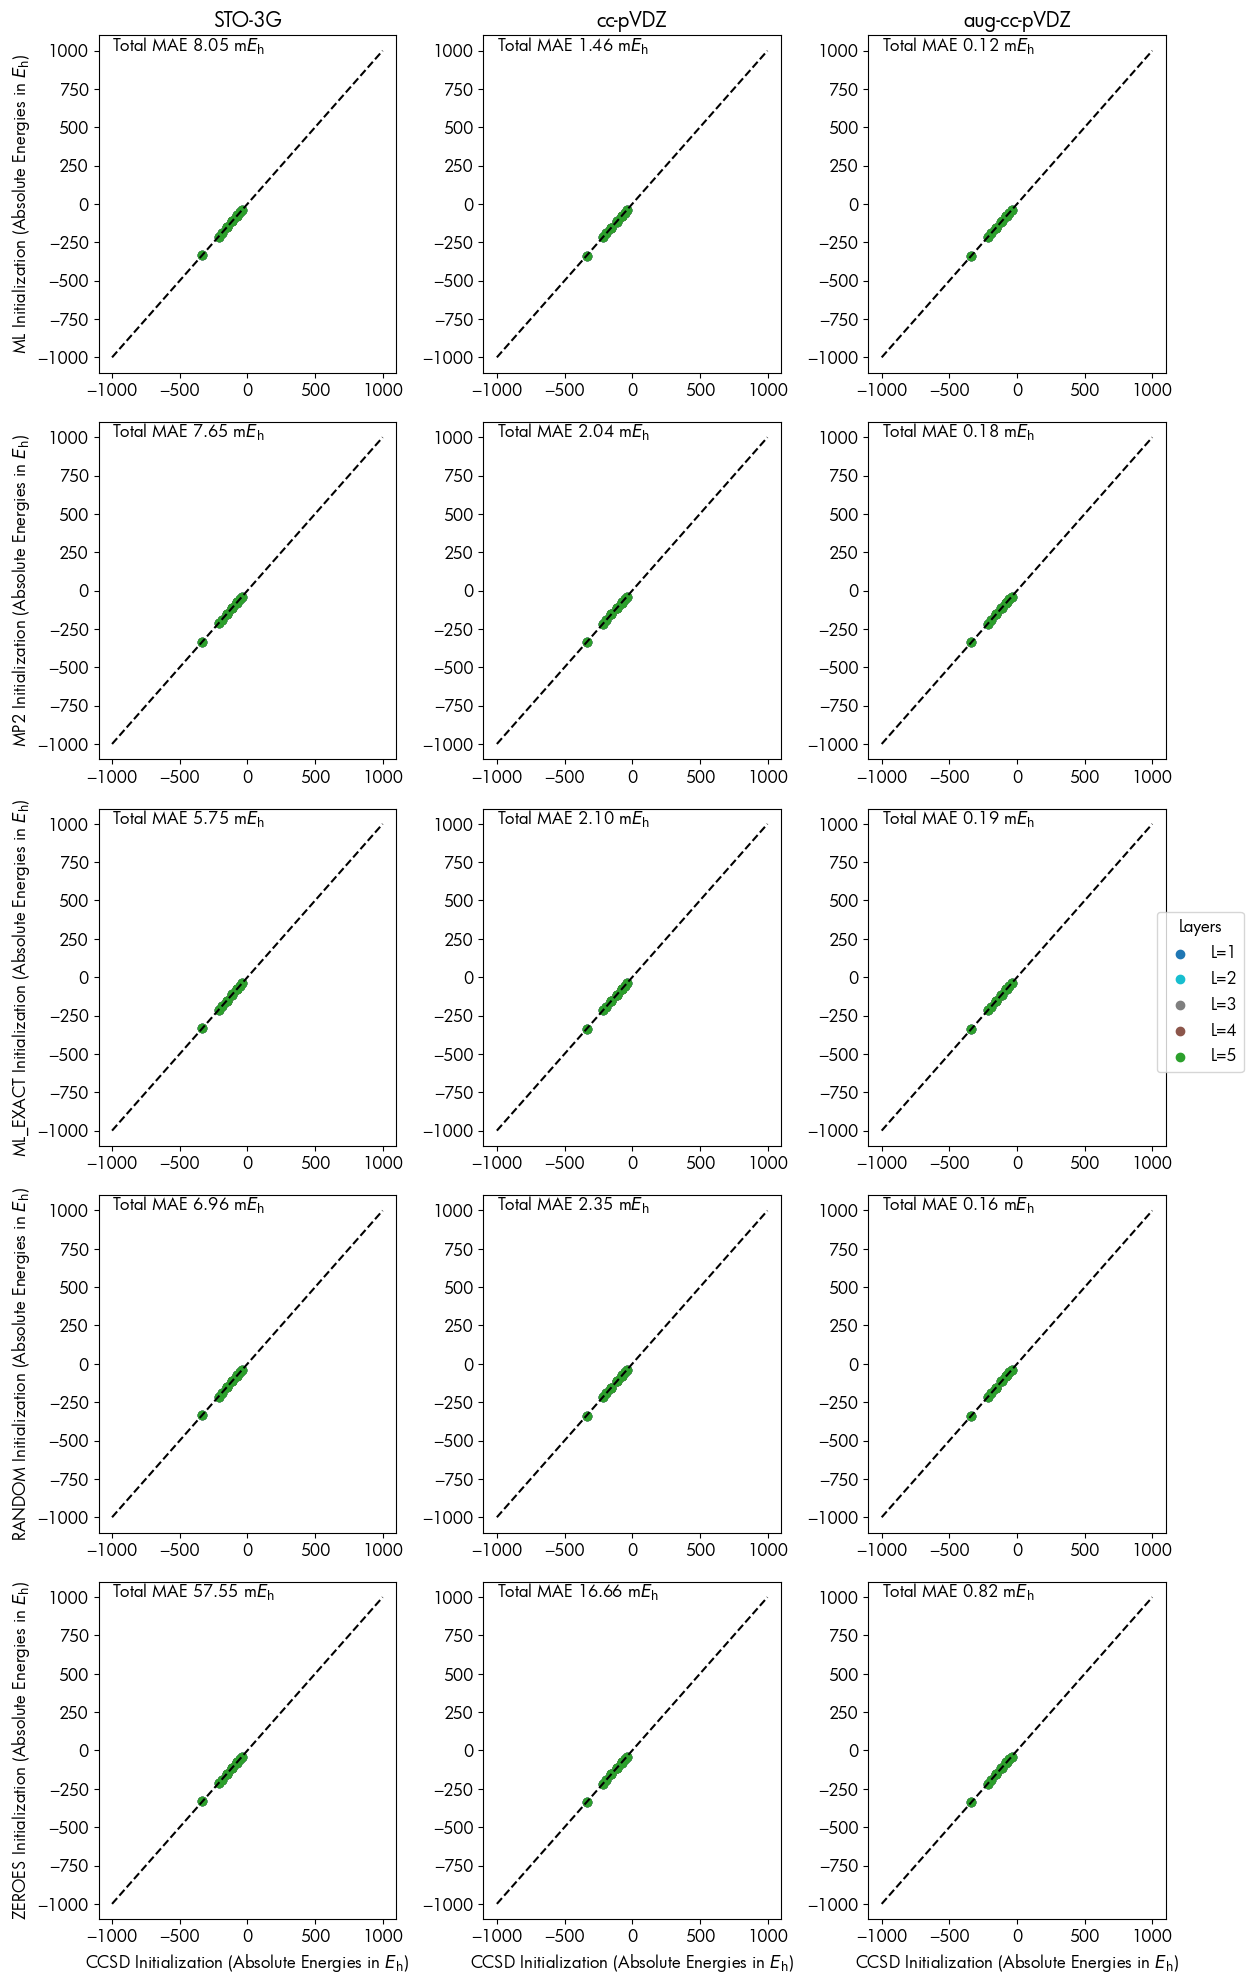

In [67]:
methods = uniqueInj[uniqueInj != 'CCSD']
n_rows = len(methods)
n_cols = len(uniqueBasis)
colors = plt.cm.tab10(np.linspace(0, 1, len(uniqueLayers)))
layer_color = dict(zip(uniqueLayers, colors))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = np.array(axes).reshape(n_rows, n_cols)

stats = []
added_labels = set()  # Fix #2: track labels to avoid duplicates

for (i, method), (j, basis) in product(enumerate(methods), enumerate(uniqueBasis)):
    ax = axes[i, j]
    all_ref, all_vals = [], []  # Fix #1: collect all data for axis limits
    # Loop layers
    for layers in sorted(uniqueLayers):
        ref_list, vals_list = [], []

        for mol in uniqueMol:
            mask = (
                (LUCJDF['Basis Set'] == basis) &
                (LUCJDF['L'] == layers) &
                (LUCJDF['Molecule'] == mol)
            )
            ref = LUCJDF.loc[(LUCJDF['Injected'] == 'CCSD') & mask, 'Energy'].values
            vals = LUCJDF.loc[(LUCJDF['Injected'] == method) & mask, 'Energy'].values

            if len(ref) == 0 or len(vals) == 0 or len(ref) != len(vals):  # Fix #3
                continue

            ref_list.extend(ref)
            vals_list.extend(vals)

        if not ref_list:
            continue

        ref_arr = np.array(ref_list)
        vals_arr = np.array(vals_list)
        all_ref.extend(ref_arr)
        all_vals.extend(vals_arr)

        label = f'L={layers}'
        ax.scatter(
            ref_arr, vals_arr,
            color=layer_color[layers],
            label=label if label not in added_labels else None,  # Fix #2
        )
        added_labels.add(label)
        stats.append((method, basis,layers, mean_absolute_error(ref_arr, vals_arr)*1e3))
    ax.text(-1000,1000,f"Total MAE {mean_absolute_error(all_vals,all_ref)*1e3:.2f}"+r" m$E_{\mathrm{h}}$")
    ax.plot(range(-1000, 1000), range(-1000, 1000), 'k--')

    # if all_ref:  # Fix #1: use aggregated data for limits
    #     ax.set_xlim(np.floor(min(all_ref)), np.ceil(max(all_ref)))
    #     ax.set_ylim(np.floor(min(all_ref)), np.ceil(max(all_ref)))

    if i == 0: ax.set_title(basis)
    if j == 0: ax.set_ylabel(method.upper()+r" Initialization (Absolute Energies in $E_{\mathrm{h}}$)")
    if i == n_rows - 1: ax.set_xlabel(r'CCSD Initialization (Absolute Energies in $E_{\mathrm{h}}$)')

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title='Layers', loc='center right', bbox_to_anchor=(1.05, 0.5))
plt.tight_layout() 
plt.savefig("GMJ_figures/parity_plots.png",dpi=300,bbox_inches='tight')

/var/folders/px/qyhp9b8j4bb0z5wgydzgkpxw0000gn/T/ipykernel_13393/249686750.py:1: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  g = sns.catplot(pd.DataFrame(stats,columns=['Method','Basis Set','Layers','MAE']),x='Method',y='MAE',hue='Layers',col='Basis Set',kind='bar',palette=palette)


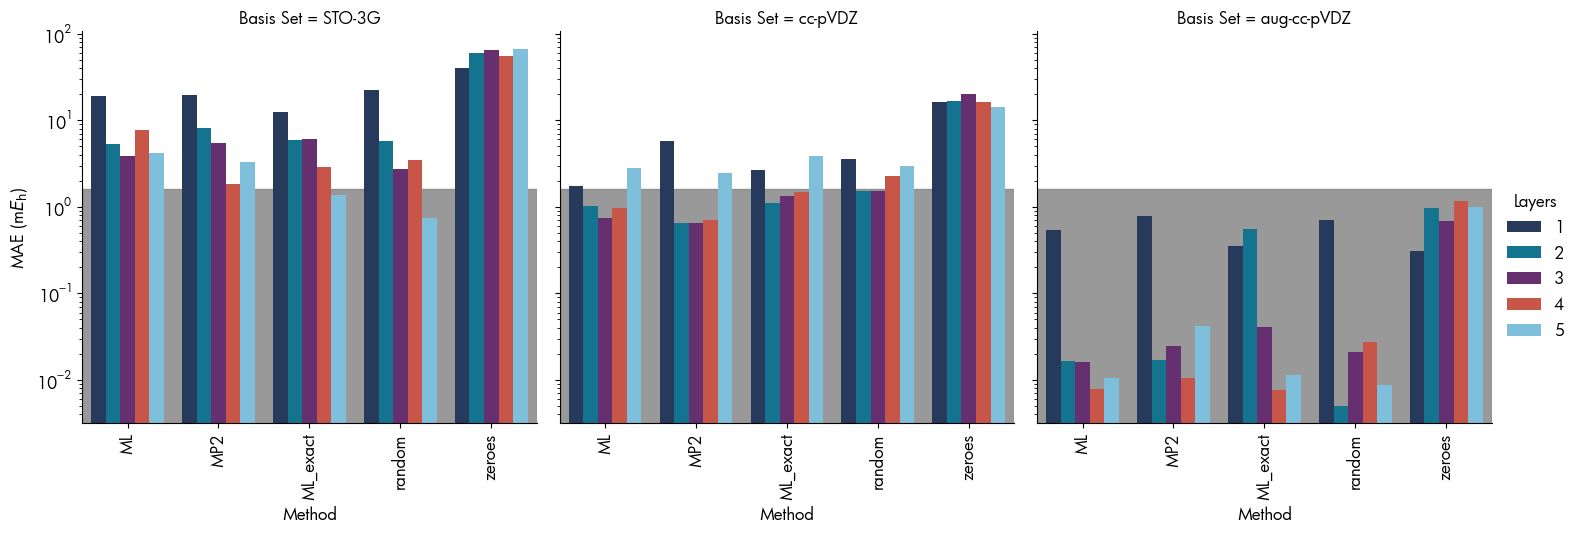

In [68]:
g = sns.catplot(pd.DataFrame(stats,columns=['Method','Basis Set','Layers','MAE']),x='Method',y='MAE',hue='Layers',col='Basis Set',kind='bar',palette=palette)
# g = sns.catplot(data=inj_mae_df,x='Molecule',y='MAE',hue='Basis',col='Injected',kind='bar',col_order=['zeroes','random','MP2','ML','ML_exact','CCSD'],palette=palette,col_wrap=3)
for ax in g.axes.flat:
    ax.set_yscale("log")
    # ax.set_ylim(ymin - pad, ymax + pad)
    ax.axhline(0, color="gray", lw=1, ls="--", alpha=0.8)
    ax.set_ylabel(r"MAE (m$E_{\mathrm{h}}$)")
    # # Gray fill region across same y-span
    # ax.fill_between(
    #     np.linspace(-0.5, len(LUCJDF["Method"].unique()) - 0.5, 100),
    #     -1.6, 1.6,
    #     color="gray", alpha=0.2
    # )
    ax.axhspan(-1.6, 1.6, color='gray', alpha=0.8, zorder=0)
    # ax.set_xlim(-0.5, len(LUCJDF["Method"].unique()) - 0.5)

    # Rotate and align x tick labels
    for label in ax.get_xticklabels():
        # print(label)
        label.set_rotation(90)
        label.set_horizontalalignment("center")
        label.set_verticalalignment("top")

In [69]:
stats

[('ML', 'STO-3G', np.int64(1), 19.220360833334855),
 ('ML', 'STO-3G', np.int64(2), 5.291336666668182),
 ('ML', 'STO-3G', np.int64(3), 3.841169166665992),
 ('ML', 'STO-3G', np.int64(4), 7.690303333334943),
 ('ML', 'STO-3G', np.int64(5), 4.200209999996929),
 ('ML', 'cc-pVDZ', np.int64(1), 1.7424516666674588),
 ('ML', 'cc-pVDZ', np.int64(2), 1.031419999999154),
 ('ML', 'cc-pVDZ', np.int64(3), 0.7364400000019108),
 ('ML', 'cc-pVDZ', np.int64(4), 0.9752458333286048),
 ('ML', 'cc-pVDZ', np.int64(5), 2.801821666668758),
 ('ML', 'aug-cc-pVDZ', np.int64(1), 0.5364866666669835),
 ('ML', 'aug-cc-pVDZ', np.int64(2), 0.016560833334011704),
 ('ML', 'aug-cc-pVDZ', np.int64(3), 0.016012500001494345),
 ('ML', 'aug-cc-pVDZ', np.int64(4), 0.007825833337212392),
 ('ML', 'aug-cc-pVDZ', np.int64(5), 0.01048083333661983),
 ('MP2', 'STO-3G', np.int64(1), 19.440824166667998),
 ('MP2', 'STO-3G', np.int64(2), 8.165667499997179),
 ('MP2', 'STO-3G', np.int64(3), 5.5109058333400185),
 ('MP2', 'STO-3G', np.int64(4),

In [70]:
stat_df = pd.DataFrame(stats,columns=['Method','Basis','Layers','MAE'])
stat_df['Ref'] = 'CCSD'

In [71]:
stat_df

,Method,Basis,Layers,MAE,Ref
0,ML,STO-3G,1,19.220361,CCSD
1,ML,STO-3G,2,5.291337,CCSD
2,ML,STO-3G,3,3.841169,CCSD
3,ML,STO-3G,4,7.690303,CCSD
4,ML,STO-3G,5,4.200210,CCSD
...,...,...,...,...,...
70,zeroes,aug-cc-pVDZ,1,0.307947,CCSD
71,zeroes,aug-cc-pVDZ,2,0.959261,CCSD
72,zeroes,aug-cc-pVDZ,3,0.685780,CCSD
73,zeroes,aug-cc-pVDZ,4,1.169099,CCSD


ValueError: could not convert string to float: 'ML'

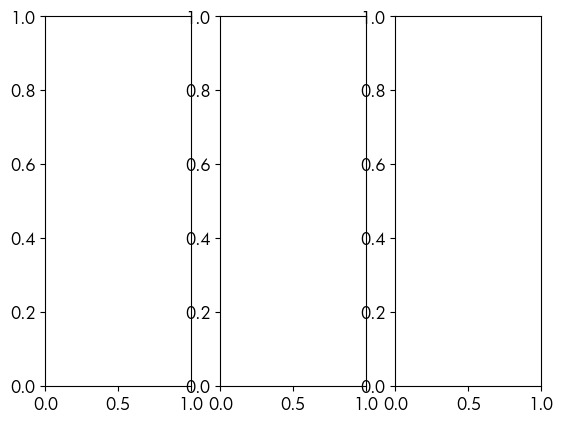

In [72]:
fig, ax = plt.subplots(1,3)
for idx,basis in enumerate(uniqueBasis):
    sns.heatmap(data=stat_df[stat_df['Basis'] == basis],ax=ax[idx],x='Method',y='Ref',hue='MAE')

In [ ]:
LUCJDF.loc[LUCJDF.loc[(LUCJDF['Injected'] == 'CCSD') & mask, 'Energy'].index]

In [ ]:
sns.kdeplot(LUCJDF['Deviation'])

In [ ]:
g = sns.catplot(LUCJDF[LUCJDF['Injected']!='CCSD'],
                col='Basis Set',
                # col='L',
                x='Molecule',
                y='Deviation',
                hue='Injected',
                kind='box',
                height=4, 
                # aspect=0.6,
                whis=(0, 100),
                )


# Compute global deviation range for consistent shading/scaling
ymin = LUCJDF["Deviation"].min()
ymax = LUCJDF["Deviation"].max()
pad = 0.1 * max(abs(ymin), abs(ymax))

# Apply styling to **all subplots**
for ax in g.axes.flat:
    ax.set_yscale("symlog", linthresh=1e-8)
    ax.set_ylim(ymin - pad, ymax + pad)
    ax.axhline(0, color="gray", lw=1, ls="--", alpha=0.8)
    
    # # Gray fill region across same y-span
    # ax.fill_between(
    #     np.linspace(-0.5, len(LUCJDF["Method"].unique()) - 0.5, 100),
    #     -1.6, 1.6,
    #     color="gray", alpha=0.2
    # )
    ax.axhspan(-1.6, 1.6, color='gray', alpha=0.8, zorder=0)
    # ax.set_xlim(-0.5, len(LUCJDF["Method"].unique()) - 0.5)

    # Rotate and align x tick labels
    for label in ax.get_xticklabels():
        # print(label)
        label.set_rotation(90)
        label.set_horizontalalignment("center")
        label.set_verticalalignment("top")

# Adjust titles and axis labels
g.set_titles(col_template="{col_name}", row_template="{row_name}")
g.set_axis_labels("Molecule", r"Energy Deviation (m$E_{\mathrm{h}}$)")


# Move legend outside the main plot (right side)
g._legend.set_bbox_to_anchor((1.1, 0.5))
g._legend.set_frame_on(False)
plt.subplots_adjust(right=0.85)  # make space for legend

plt.tight_layout()
plt.show()

In [ ]:
g = sns.catplot(data=LUCJDF, y='Deviation', x='Injected', hue='Basis Set', col='L', kind='box',
                whis=(0, 100))  # or whis=np.inf

for ax in g.axes.flat:
    ax.set_yscale('symlog')
    ax.axhspan(-1.6, 1.6, color='gray', alpha=0.8, zorder=0)

In [ ]:
sns.color_palette("colorblind").as_hex()

In [ ]:
for i in sns.color_palette("colorblind").as_hex():
    print(i)

In [ ]:
LUCJDF['Deviation'].describe()

# Stack all data

In [ ]:
energyDF

In [ ]:
for a,b in moldf[['molecule','mol_filename']].values:
    if 'GDB' in b:
        name = b.replace('.xyz','')
        energyDF['Name'] = energyDF['Name'].replace(name,a)

In [ ]:
energyDF['L'] = len(energyDF)*[np.nan]
energyDF['Injected'] = len(energyDF)*[np.nan]

In [ ]:
upDF = pd.concat([energyDF,LUCJDF]).reset_index().drop(columns=['index'])
upDF['Deviation'] = np.nan

In [ ]:
moldf

In [ ]:
n_atoms_dict = {
    'water': 3,
    'methane': 5,
    'ammonia': 4,
    'ethane': 8,
    'methanol': 6,
    'ethylene': 6,
    'formaldehyde': 4,
    "prop-2-en-1-ol":10,
    "but-1-yne":10,
    "fluoroform":5,
    "buta-1,3-diene":10,
    "(Z)-1-fluoroprop-1-ene":9
}

upDF['n_atoms'] = upDF['Molecule'].map(n_atoms_dict)

In [ ]:
upDF.sort_values(by=['n_atoms'])

In [ ]:
g = sns.catplot(LUCJDF,
                row='Basis Set',
                col='L',
                x='Molecule',
                y='Energy',
                hue='Injected',
                kind='bar',
                height=4,
                aspect=0.6,
                )

# Adjust titles and axis labels
g.set_titles(col_template="Layers={col_name}", row_template="{row_name}")
g.set_axis_labels("Method", r"Energies (m$E_{\mathrm{h}}$)")


# Move legend outside the main plot (right side)
g._legend.set_bbox_to_anchor((1.1, 0.5))
g._legend.set_frame_on(False)
plt.subplots_adjust(right=0.85)  # make space for legend

plt.tight_layout()
plt.show()

In [ ]:
refmethod = "CASCI"
for mol in uniqueMol:
    for basis in uniqueBasis:
        # Get the CASCI reference energy (scalar)
        casci_row = upDF.loc[
            (upDF["Molecule"] == mol)
            & (upDF["Method"] == refmethod)
            & (upDF["Basis Set"] == basis),
            "Energy",
        ]
        if casci_row.empty:
            continue  # skip if no CASCI reference for this (mol, basis)
        casci_e = casci_row.values[0]  # extract scalar

        # Compute deviations for other methods with the same mol/basis
        mask = (
            (upDF["Molecule"] == mol)
            & (upDF["Basis Set"] == basis)
            # & (upDF["Method"] != refmethod)
        )
        # print(upDF.loc[mask, "Energy"]- casci_e)
        upDF.loc[mask, "Deviation"] = (upDF.loc[mask, "Energy"] - casci_e)*1e3
        # print(upDF.loc[mask, "Energy"] - casci_e)

In [ ]:
#sns.relplot(data=upDF, x="total_bill", y="tip", hue="day", col="time", row="sex")

In [ ]:
upDF

In [ ]:
heatmap_data = upDF.pivot_table(values='Deviation', index='Molecule', columns='Basis Set', aggfunc='mean') # here aggfunc mean computes the mean deviation
sns.heatmap(heatmap_data, annot=True, cmap='Blues')
plt.title('Mean deviation', pad=20)
plt.tight_layout()
plt.show()

In [ ]:
upDF.head()

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=upDF,
    x='n_atoms',
    y='Deviation',
    hue='Method'
)
plt.yscale('symlog')
plt.xlabel("Number of Atoms (Molecule Size)")

plt.ylabel(r"Energy Deviation $\mathrm{kcal\,mol^{-1}}$")
plt.tight_layout()
plt.show()


In [ ]:
sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=upDF,
    x='n_atoms',
    y='Deviation',
    hue='Method',
    palette='Set2',
    fliersize=0 
)
sns.stripplot(
    data=upDF,
    x='n_atoms',
    y='Deviation',
    hue='Method',
    dodge=True,
    color='k',
    alpha=0.6,
    size=4
)

plt.yscale('symlog', linthresh=1e-3)
plt.xlabel("Number of Atoms")
plt.ylabel(r"Energy Deviation $\mathrm{kcal\,mol^{-1}}$")

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:len(uniqueMethods)], labels[:len(uniqueMethods)], title="Method", fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
upDF

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=upDF,
    x='Injected',      # categorical injection method
    y='Deviation',
    hue='Method',
    palette='Set2',
    fliersize=0
)
sns.stripplot(
    data=upDF,
    x='Injected',
    y='Deviation',
    hue='Method',
    dodge=True,
    color='k',
    alpha=0.6,
    size=4
)

plt.yscale('symlog', linthresh=1e-3)
plt.xlabel("Injection Method")
plt.ylabel(r"Energy Deviation $\mathrm{kcal\,mol^{-1}}$")
plt.title("Energy Deviation by Injection Method and Computational Method")

# Simplify legend
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:len(uniqueMethods)], labels[:len(uniqueMethods)], title="Method", fontsize=12, bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
sns.swarmplot(
    data=upDF,
    x='Method',
    y='Deviation',
    hue='Molecule'
)

plt.ylabel(r"Energy Deviation $\mathrm{kcal\,mol^{-1}}$")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12)
plt.show()

In [ ]:
sns.pairplot(upDF, hue="Method")